In [ ]:
!pip uninstall -y wfdb numpy pandas
!pip install --upgrade pip
!pip install wfdb numpy pandas


Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 26.8 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 142.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 163.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [wfdb]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.

In [ ]:
!pip install wfdb pywavelets seaborn scikit-learn



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
from scipy import stats,signal
import wfdb
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns

plt.rcParams["figure.figsize"] = (16,5)
plt.rcParams["axes.grid"] = True

In [ ]:
# Loading the mit-arrythmia dataset

import time
from wfdb.io._url import NetFileError # Import NetFileError explicitly

record_ids = wfdb.get_record_list('mitdb')

ecg_records = {}
ecg_annotations = {} # Corrected typo from ec_annotations

for record_name in record_ids:
    retries = 3
    for attempt in range(retries):
        try:
            signal_record = wfdb.rdrecord(record_name, pn_dir='mitdb')
            beat_annotation = wfdb.rdann(record_name, 'atr', pn_dir='mitdb')

            ecg_records[record_name] = signal_record.p_signal[:, 0]   # Use Lead 1
            ecg_annotations[record_name] = {
                "beat_symbols": beat_annotation.symbol,
                "beat_samples": beat_annotation.sample
            }
            print(f"Successfully loaded record: {record_name}")
            break  # Exit retry loop on success
        except NetFileError as e: # Use the imported NetFileError
            print(f"Error loading record {record_name} (attempt {attempt + 1}/{retries}): {e}")
            if attempt < retries - 1:
                time.sleep(5)  # Wait before retrying
            else:
                print(f"Failed to load record {record_name} after multiple attempts. Skipping this record.")

print(f"Total Records Loaded: {len(ecg_records)}")

Successfully loaded record: 100
Successfully loaded record: 101
Successfully loaded record: 102
Successfully loaded record: 103
Successfully loaded record: 104
Successfully loaded record: 105
Successfully loaded record: 106
Successfully loaded record: 107
Successfully loaded record: 108
Successfully loaded record: 109
Successfully loaded record: 111
Successfully loaded record: 112
Successfully loaded record: 113
Successfully loaded record: 114
Successfully loaded record: 115
Successfully loaded record: 116
Successfully loaded record: 117
Successfully loaded record: 118
Successfully loaded record: 119
Successfully loaded record: 121
Successfully loaded record: 122
Successfully loaded record: 123
Successfully loaded record: 124
Successfully loaded record: 200
Successfully loaded record: 201
Successfully loaded record: 202
Successfully loaded record: 203
Successfully loaded record: 205
Successfully loaded record: 207
Successfully loaded record: 208
Successfully loaded record: 209
Successf

In [ ]:
# AAMI(Association for the Advancement of Medical Instrumentation) standard class mapping

aami_mapping = {
    'N': 'N', 'L': 'N', 'R': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
    '/': 'Q', 'f': 'Q', 'Q': 'Q'
}

aami_classes = ['N', 'S', 'V', 'F', 'Q']
class_to_index = {label: idx for idx, label in enumerate(aami_classes)}



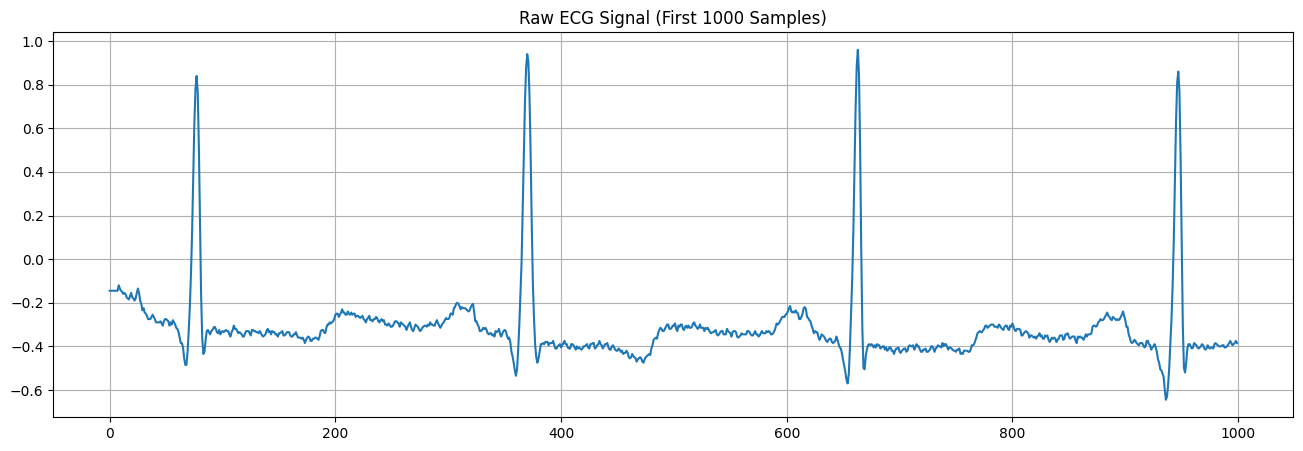

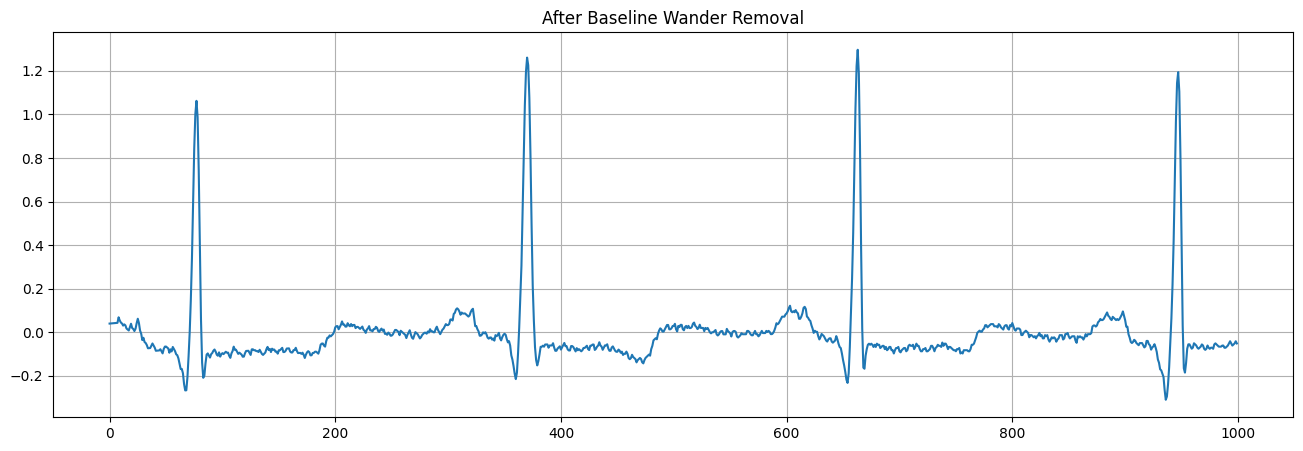

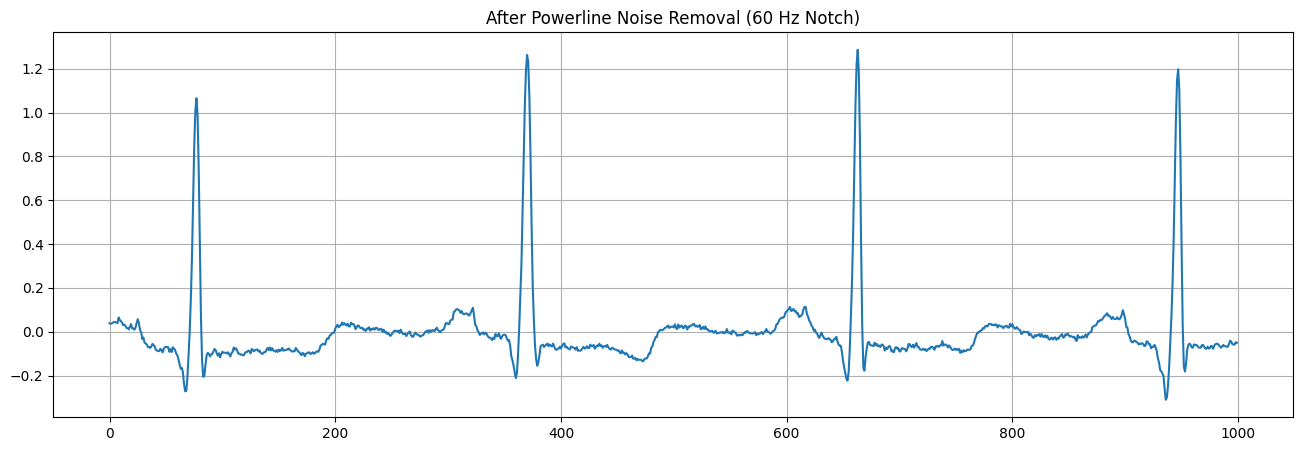

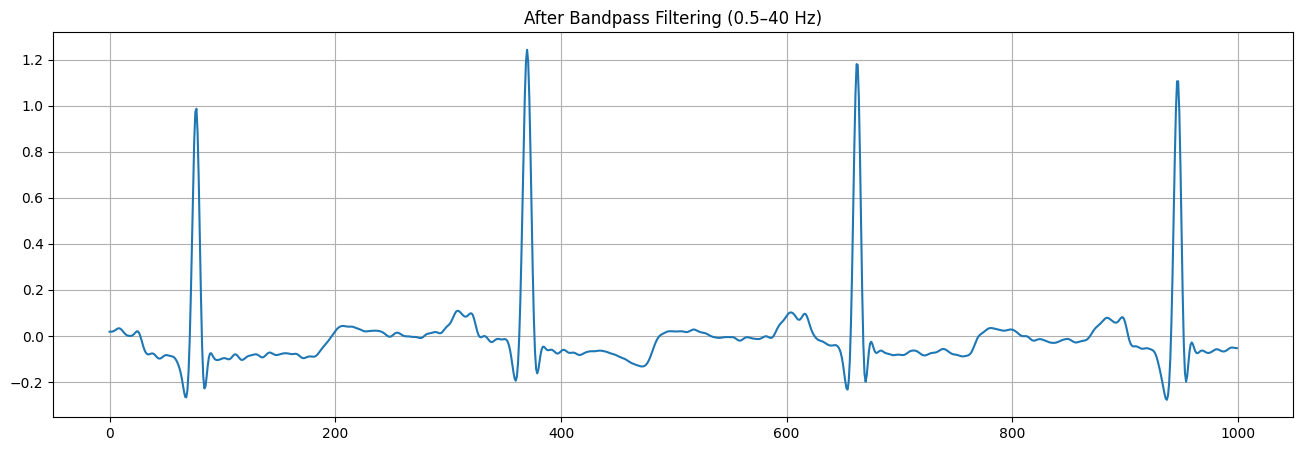

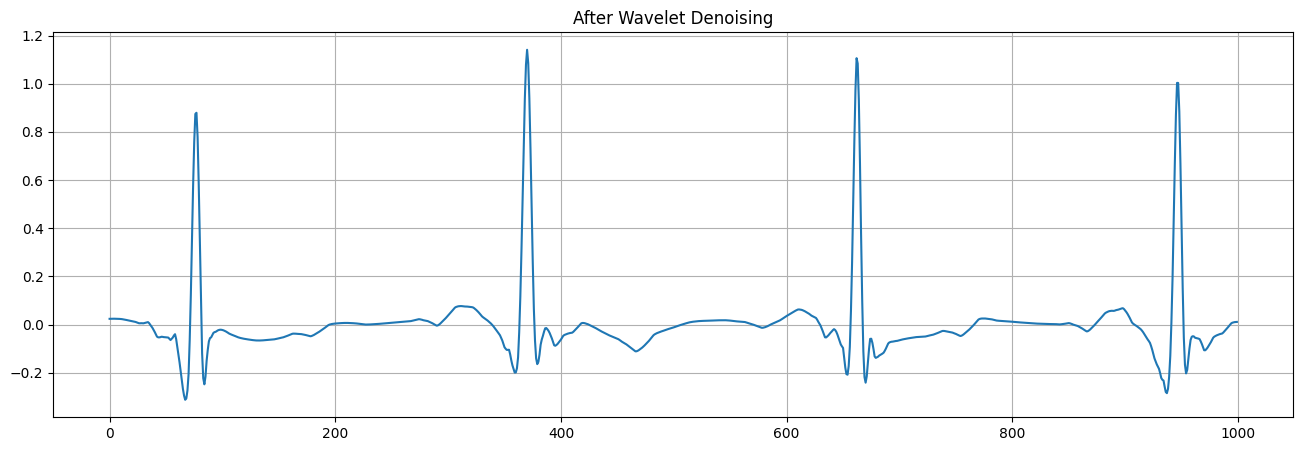

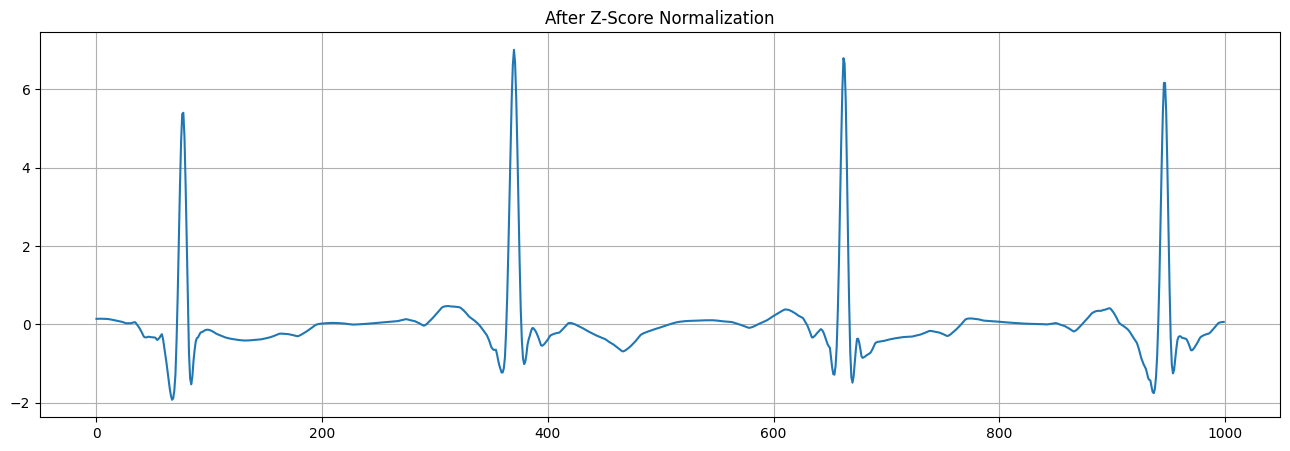

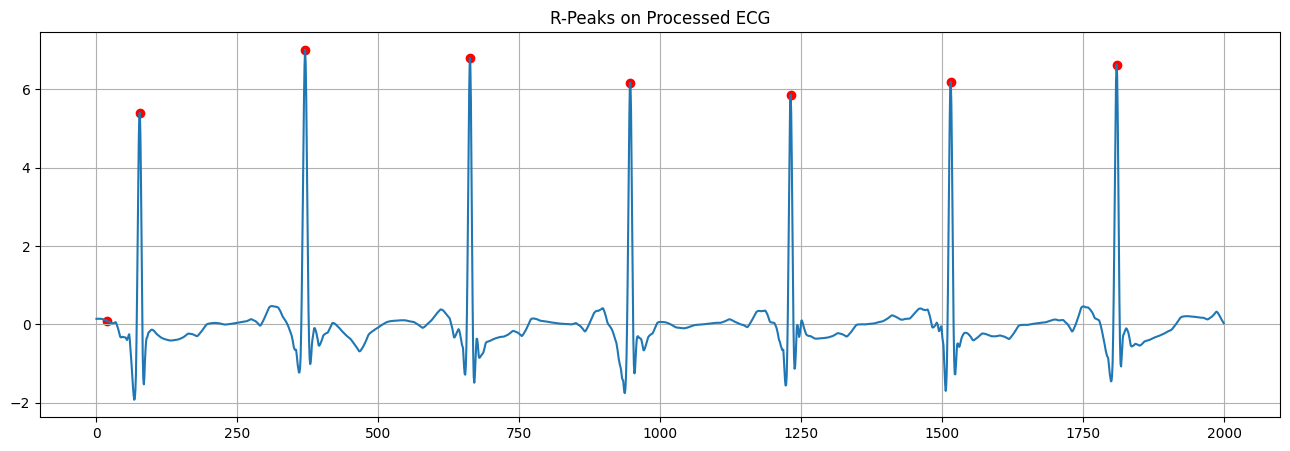

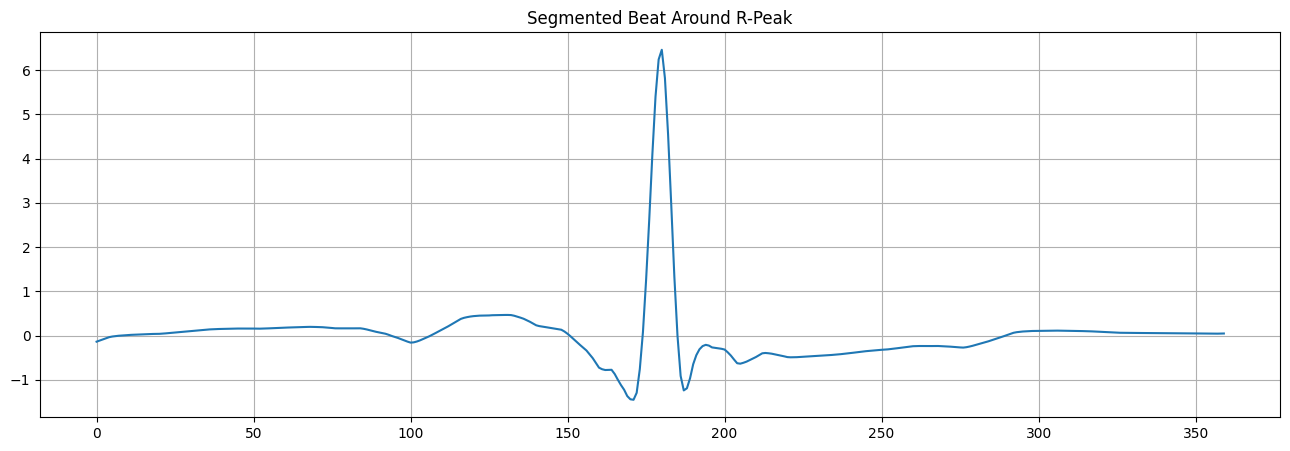

In [ ]:
# Data pre-processing part

#One example for visualization purposes on each step of data pre-processing
example_record = list(ecg_records.keys())[0]
sampling_rate = 360  # MIT-BIH standard
raw_signal = ecg_records[example_record]


# Raw ECG visualization
plt.title("Raw ECG Signal (First 1000 Samples)")
plt.plot(raw_signal[:1000])
plt.show()


#Baseline Wander Removal
highpass_cutoff = 0.5
b, a = signal.butter(4, highpass_cutoff/(sampling_rate/2), btype='high')
baseline_removed = signal.filtfilt(b, a, raw_signal)

plt.title("After Baseline Wander Removal")
plt.plot(baseline_removed[:1000])
plt.show()

#Powerline Noise removal
notch_freq = 60.0
quality_factor = 30.0

b_notch, a_notch = signal.iirnotch(notch_freq/(sampling_rate/2), quality_factor)
notch_filtered = signal.filtfilt(b_notch, a_notch, baseline_removed)

plt.title("After Powerline Noise Removal (60 Hz Notch)")
plt.plot(notch_filtered[:1000])
plt.show()


# Bandpass filter
lowcut = 0.5
highcut = 40.0
b_band, a_band = signal.butter(
    4,
    [lowcut/(sampling_rate/2), highcut/(sampling_rate/2)],
    btype='band'
)

bandpassed_signal = signal.filtfilt(b_band, a_band, notch_filtered)

plt.title("After Bandpass Filtering (0.5–40 Hz)")
plt.plot(bandpassed_signal[:1000])
plt.show()


# Wavelet denoising
wavelet = pywt.Wavelet('sym4')
max_level = pywt.dwt_max_level(len(bandpassed_signal), wavelet.dec_len)

coeffs = pywt.wavedec(bandpassed_signal, 'sym4', level=max_level)

for level in range(1, len(coeffs)):
    threshold = 0.04 * np.max(coeffs[level])
    coeffs[level] = pywt.threshold(coeffs[level], threshold)

wavelet_denoised = pywt.waverec(coeffs, 'sym4')
wavelet_denoised = wavelet_denoised[:len(bandpassed_signal)]

plt.title("After Wavelet Denoising")
plt.plot(wavelet_denoised[:1000])
plt.show()


# Z-score Normalisation
normalized_signal = stats.zscore(wavelet_denoised)
plt.title("After Z-Score Normalization")
plt.plot(normalized_signal[:1000])
plt.show()


##### Exploratory Data Analysis (EDA)

#R-peak visualisation
r_positions = ecg_annotations[example_record]["beat_samples"]

plt.figure()
plt.title("R-Peaks on Processed ECG")
plt.plot(normalized_signal[:2000])
plt.scatter(r_positions[r_positions < 2000],
            normalized_signal[r_positions[r_positions < 2000]],
            color='red')
plt.show()


#Beat Segmentation visualisation
window_radius = 180
first_r = r_positions[10]
beat_segment = normalized_signal[
    first_r-window_radius : first_r+window_radius
]
plt.title("Segmented Beat Around R-Peak")
plt.plot(beat_segment)
plt.show()


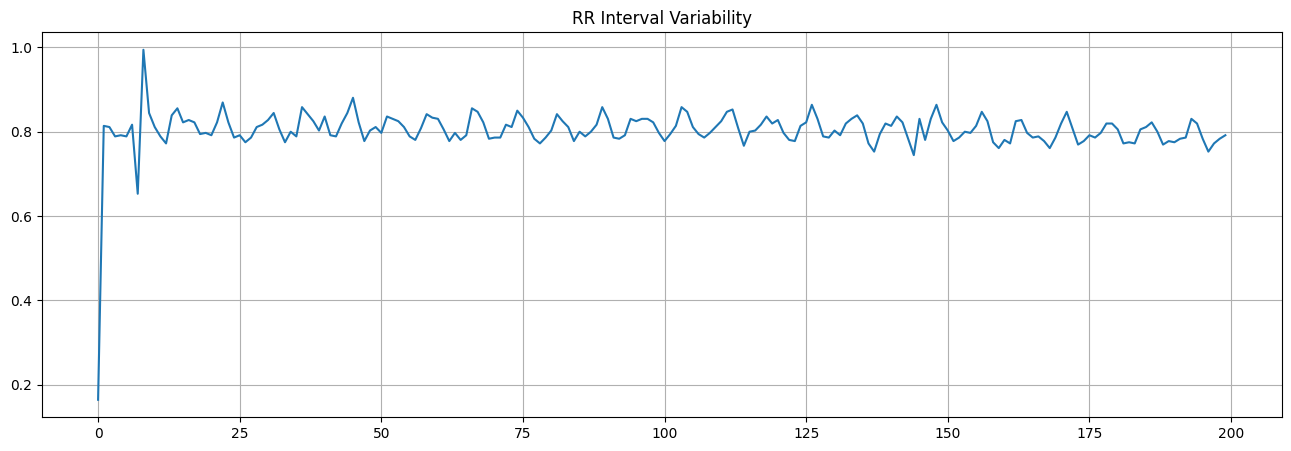

In [ ]:
rr_intervals = np.diff(r_positions) / sampling_rate

plt.title("RR Interval Variability")
plt.plot(rr_intervals[:200])
plt.show()


In [ ]:
#### RR Interval statistics
mean_rr = np.mean(rr_intervals)
std_rr = np.std(rr_intervals)

print("Mean RR:", mean_rr)
print("STD RR:", std_rr)


Mean RR: 0.7943161265092633
STD RR: 0.05058434099145012


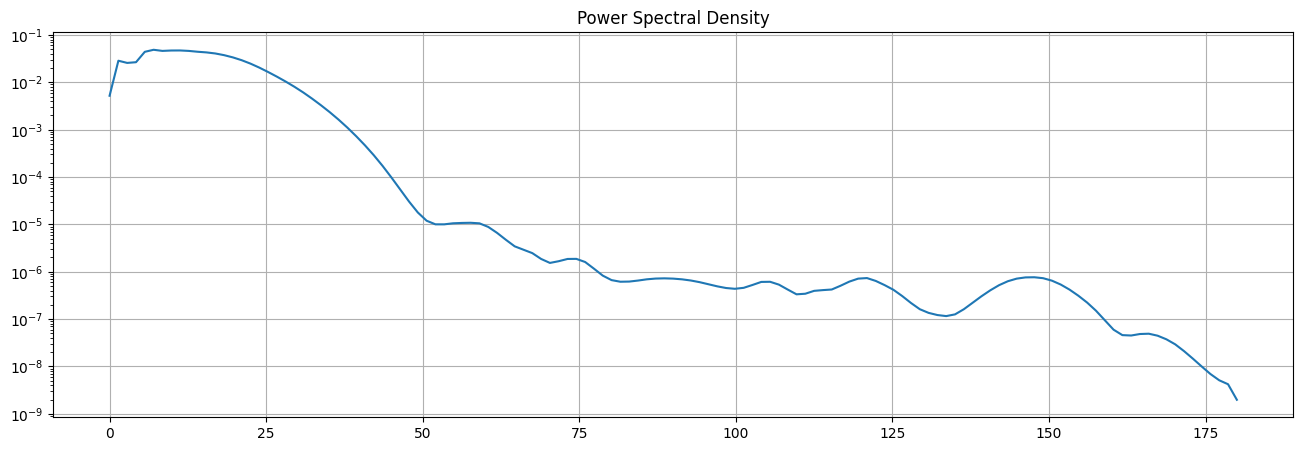

In [ ]:
#### Frequency Domain Analysis
frequencies, power_spectrum = signal.welch(normalized_signal, sampling_rate)

plt.title("Power Spectral Density")
plt.semilogy(frequencies, power_spectrum)
plt.show()


In [ ]:
### The preprocessing pipeline described previously is applied consistently across all ECG records to generate the final dataset.
###Beat segmentation is performed around detected R-peaks, and corresponding labels are assigned based on AAMI classification.
all_beats = []
all_labels = []
window_radius = 180
sampling_rate = 360 # MIT-BIH standard


for record_name in ecg_records.keys():
    raw_signal = ecg_records[record_name]
    beat_samples = ecg_annotations[record_name]["beat_samples"]
    beat_symbols = ecg_annotations[record_name]["beat_symbols"]

    # Baseline Wander Removal
    highpass_cutoff = 0.5
    b, a = signal.butter(4, highpass_cutoff/(sampling_rate/2), btype='high')
    baseline_removed = signal.filtfilt(b, a, raw_signal)

    notch_freq = 60.0
    quality_factor = 30.0
    b_notch, a_notch = signal.iirnotch(notch_freq/(sampling_rate/2), quality_factor)
    notch_filtered = signal.filtfilt(b_notch, a_notch, baseline_removed)

    lowcut = 0.5
    highcut = 40.0
    b_band, a_band = signal.butter(
        4,
        [lowcut/(sampling_rate/2), highcut/(sampling_rate/2)],
        btype='band'
    )
    bandpassed_signal = signal.filtfilt(b_band, a_band, notch_filtered)

    wavelet = pywt.Wavelet('sym4')
    max_level = pywt.dwt_max_level(len(bandpassed_signal), wavelet.dec_len)
    coeffs = pywt.wavedec(bandpassed_signal, 'sym4', level=max_level)
    for level in range(1, len(coeffs)):
        threshold = 0.04 * np.max(coeffs[level])
        coeffs[level] = pywt.threshold(coeffs[level], threshold)
    wavelet_denoised = pywt.waverec(coeffs, 'sym4')
    wavelet_denoised = wavelet_denoised[:len(bandpassed_signal)]

    normalized_signal = stats.zscore(wavelet_denoised)

    # Segment beats and assign labels
    for i, sample in enumerate(beat_samples):
        # Ensure beat segment is within signal boundaries
        if sample - window_radius >= 0 and sample + window_radius <= len(normalized_signal):
            beat_segment = normalized_signal[sample - window_radius : sample + window_radius]
            # Map beat symbol to AAMI class
            symbol = beat_symbols[i]
            if symbol in aami_mapping:
                aami_class = aami_mapping[symbol]
                label_index = class_to_index[aami_class]
                all_beats.append(beat_segment)
                all_labels.append(label_index)

# Convert to numpy arrays
ecg_beats = np.array(all_beats)
ecg_labels = np.array(all_labels)

print("Final ECG Beat Dataset Shape:", ecg_beats.shape)
print("Final Label Shape:", ecg_labels.shape)


Final ECG Beat Dataset Shape: (109193, 360)
Final Label Shape: (109193,)


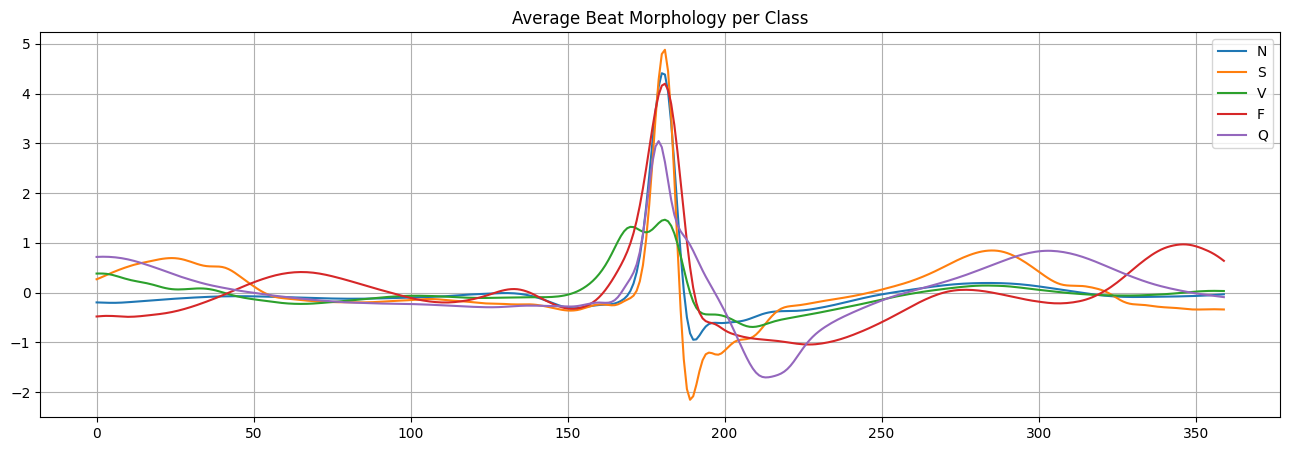

In [ ]:
#Morphological Analysis of ECG Beats
for class_id in np.unique(ecg_labels):
    class_beats = ecg_beats[ecg_labels == class_id]
    mean_waveform = np.mean(class_beats, axis=0)

    plt.plot(mean_waveform, label=aami_classes[class_id])

plt.title("Average Beat Morphology per Class")
plt.legend()
plt.show()


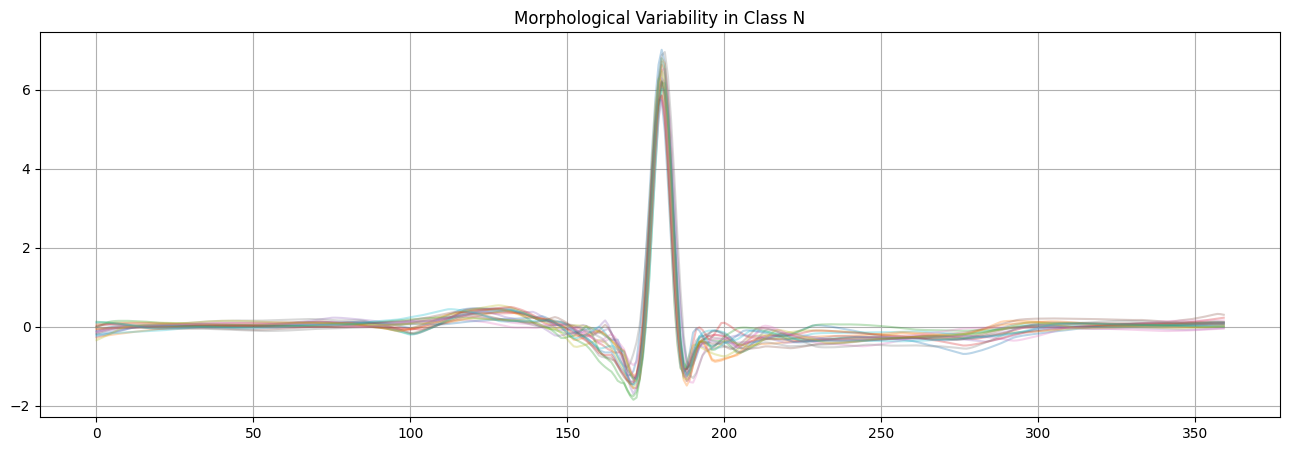

In [ ]:
#### Intra-class variability analysis
class_id = 0  # example V class
class_beats = ecg_beats[ecg_labels == class_id]

plt.figure()
for i in range(20):
    plt.plot(class_beats[i], alpha=0.3)

plt.title("Morphological Variability in Class N")
plt.show()

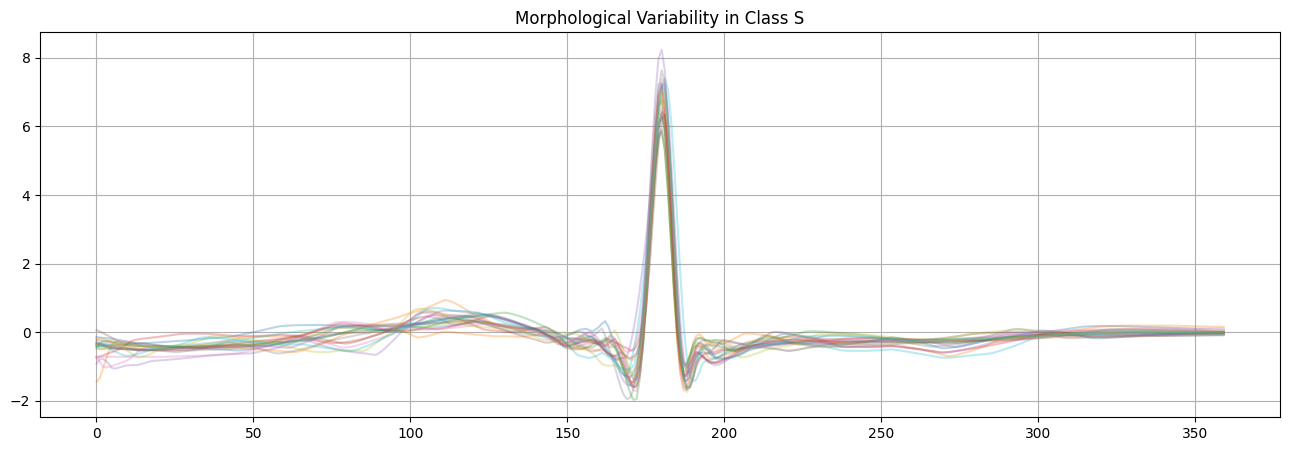

In [ ]:
class_id = 1  # example V class
class_beats = ecg_beats[ecg_labels == class_id]

plt.figure()
for i in range(20):
    plt.plot(class_beats[i], alpha=0.3)

plt.title("Morphological Variability in Class S")
plt.show()

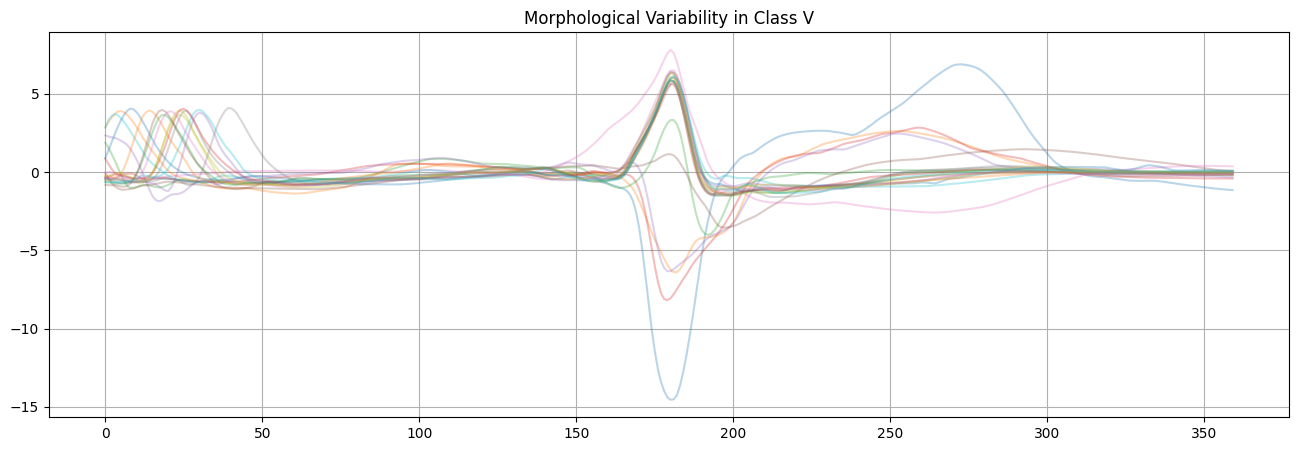

In [ ]:
class_id = 2  # example V class
class_beats = ecg_beats[ecg_labels == class_id]

plt.figure()
for i in range(20):
    plt.plot(class_beats[i], alpha=0.3)

plt.title("Morphological Variability in Class V")
plt.show()


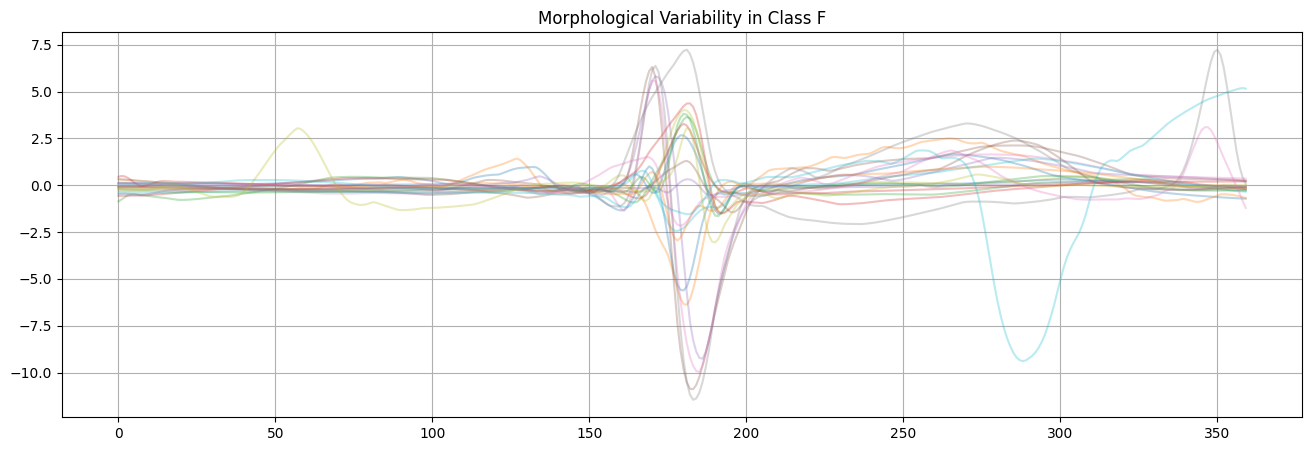

In [ ]:
class_id = 3  # example V class
class_beats = ecg_beats[ecg_labels == class_id]

plt.figure()
for i in range(20):
    plt.plot(class_beats[i], alpha=0.3)

plt.title("Morphological Variability in Class F")
plt.show()

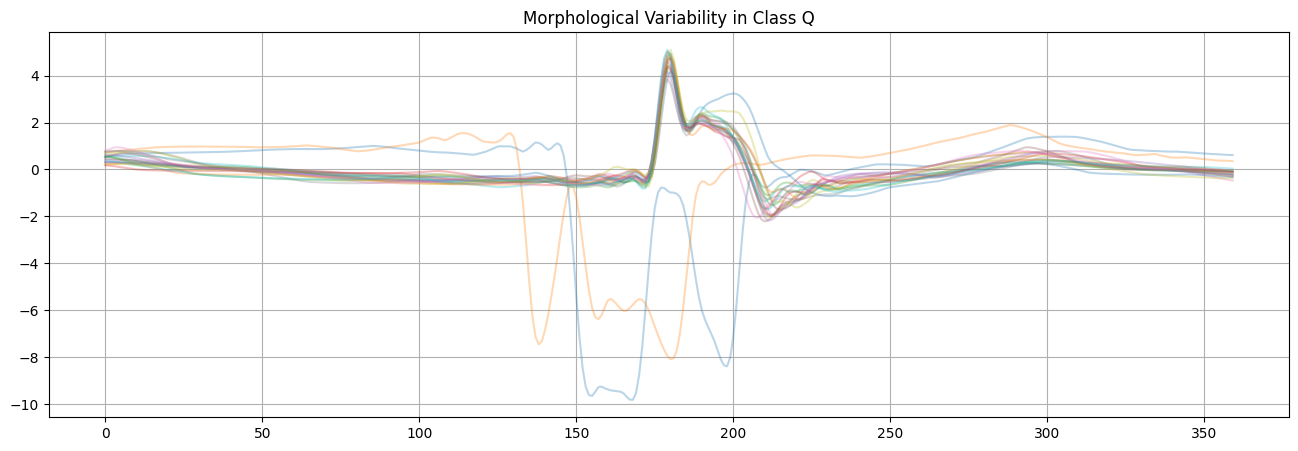

In [ ]:
class_id = 4  # example V class
class_beats = ecg_beats[ecg_labels == class_id]

plt.figure()
for i in range(20):
    plt.plot(class_beats[i], alpha=0.3)

plt.title("Morphological Variability in Class Q")
plt.show()

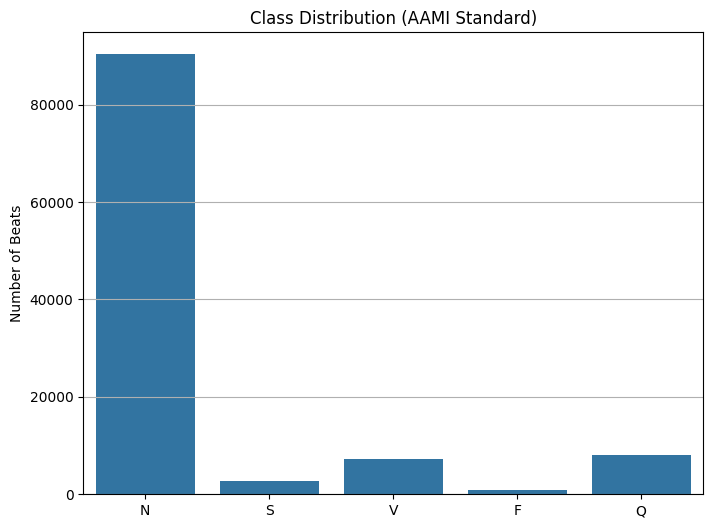

0    90337
1     2781
2     7235
3      802
4     8038
Name: count, dtype: int64


In [ ]:
### Class Imbalance Visualization
class_distribution = pd.Series(ecg_labels).value_counts().sort_index()

plt.figure(figsize=(8,6))
sns.barplot(x=aami_classes, y=class_distribution.values)
plt.title("Class Distribution (AAMI Standard)")
plt.ylabel("Number of Beats")
plt.show()

print(class_distribution)


Unified pipeline Trial

In [ ]:
## Train and test split
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    ecg_beats,
    ecg_labels,
    test_size=0.2,
    random_state=42,
    stratify=ecg_labels   # keeps class balance
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (87354, 360)
Test shape : (21839, 360)


In [ ]:
# one hot encoding
from tensorflow.keras.utils import to_categorical
import numpy as np

num_classes = 5

y_train = to_categorical(y_train, num_classes)
y_test  = to_categorical(y_test, num_classes)


# Class weights
from sklearn.utils.class_weight import compute_class_weight

y_train_int = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)

class_weight_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weight_dict)

# Convert to alpha (for focal loss)
alpha = np.array([class_weight_dict[i] for i in range(num_classes)])
alpha = alpha / np.sum(alpha)

print("Alpha:", alpha)


# Re-shape logic for CNN, 1D Resnet and Transformer-CNN Hybrid
X_train = X_train.reshape(X_train.shape[0], 360, 1)
X_test  = X_test.reshape(X_test.shape[0], 360, 1)

print("Final Train shape:", X_train.shape)
print("Final Test shape :", X_test.shape)

# Check before training
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("Alpha :", alpha)

Class Weights: {0: np.float64(0.24174680706803747), 1: np.float64(7.852044943820225), 2: np.float64(3.01845196959226), 3: np.float64(27.213084112149534), 4: np.float64(2.717076205287714)}
Alpha: [0.00589017 0.19131542 0.07354472 0.663048   0.06620168]
Final Train shape: (87354, 360, 1)
Final Test shape : (21839, 360, 1)
X_train: (87354, 360, 1)
y_train: (87354, 5)
Alpha : [0.00589017 0.19131542 0.07354472 0.663048   0.06620168]


In [ ]:
#### MAIN COMMON TRAIN AND SAVE PIPELINE

import os, json, datetime
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt


def train_and_save(model, model_name, X_train, X_test, y_train, y_test, alpha,
                   lr=0.0005, batch_size=128, epochs=30,
                   gamma=2.0, threshold=None):   #  NEW PARAMS

    #  FOCAL LOSS (NOW INCLUDED HERE)
    def categorical_focal_loss(alpha, gamma=2.0):
        alpha_tensor = tf.constant(alpha, dtype=tf.float32)

        def loss(y_true, y_pred):
            y_pred = tf.clip_by_value(y_pred, 1e-7, 1. - 1e-7)
            cross_entropy = -y_true * tf.math.log(y_pred)
            weight = alpha_tensor * tf.pow(1 - y_pred, gamma)
            loss_val = weight * cross_entropy
            return tf.reduce_mean(tf.reduce_sum(loss_val, axis=1))

        return loss


    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    SAVE_DIR = f"/content/drive/MyDrive/new_{model_name}_{timestamp}"
    os.makedirs(SAVE_DIR, exist_ok=True)

    # Compile
    focal_loss = categorical_focal_loss(alpha=alpha, gamma=gamma)

    model.compile(
        loss=focal_loss,
        optimizer=Adam(learning_rate=lr),
        metrics=['accuracy']
    )

    # Callback
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

    checkpoint = ModelCheckpoint(
        filepath=os.path.join(SAVE_DIR, "best_model.keras"),
        monitor='val_loss',
        save_best_only=True
    )

    # Train
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        callbacks=[early_stop, reduce_lr, checkpoint],
        verbose=1
    )


    # Evaluation
    results = model.evaluate(X_test, y_test)

    pred_probs = model.predict(X_test)

    #  Threshold logic only if provided
    if threshold is not None:
        pred_classes = []
        for probs in pred_probs:
            if probs[3] > threshold:
                pred_classes.append(3)
            else:
                pred_classes.append(np.argmax(probs))
        pred_classes = np.array(pred_classes)
    else:
        pred_classes = np.argmax(pred_probs, axis=1)

    true_classes = np.argmax(y_test, axis=1)


    # Classification report
    print("\n Classification Report:")
    print(classification_report(true_classes, pred_classes))


    # Macro F1 Score
    macro_f1 = f1_score(true_classes, pred_classes, average='macro')
    print(" Macro F1 Score:", macro_f1)


    # Confusion matrix
    conf_matrix = confusion_matrix(true_classes, pred_classes)
    conf_matrix = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(6,6))
    plt.imshow(conf_matrix, cmap=plt.cm.Blues)
    plt.title("Normalized Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()

    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            plt.text(j, i, f"{conf_matrix[i,j]:.2f}", ha='center', color='red')

    plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"))
    plt.show()


    # Save the results to google drive
    model.save(os.path.join(SAVE_DIR, "final_model.keras"))

    np.save(os.path.join(SAVE_DIR, "X_train.npy"), X_train)
    np.save(os.path.join(SAVE_DIR, "X_test.npy"), X_test)
    np.save(os.path.join(SAVE_DIR, "y_train.npy"), y_train)
    np.save(os.path.join(SAVE_DIR, "y_test.npy"), y_test)

    np.save(os.path.join(SAVE_DIR, "y_pred.npy"), pred_classes)
    np.save(os.path.join(SAVE_DIR, "y_probs.npy"), pred_probs)

    with open(os.path.join(SAVE_DIR, "results.json"), "w") as f:
        json.dump({
            "test_loss": float(results[0]),
            "test_accuracy": float(results[1]),
            "macro_f1": float(macro_f1)
        }, f)

    with open(os.path.join(SAVE_DIR, "history.json"), "w") as f:
        json.dump(history.history, f)

    print(f" Saved: new_{model_name}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.8305 - loss: 0.0046 - val_accuracy: 0.8849 - val_loss: 0.0026 - learning_rate: 5.0000e-04
Epoch 2/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.9008 - loss: 0.0023 - val_accuracy: 0.8146 - val_loss: 0.0024 - learning_rate: 5.0000e-04
Epoch 3/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9210 - loss: 0.0017 - val_accuracy: 0.9543 - val_loss: 0.0015 - learning_rate: 5.0000e-04
Epoch 4/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9383 - loss: 0.0013 - val_accuracy: 0.9317 - val_loss: 0.0014 - learning_rate: 5.0000e-04
Epoch 5/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9436 - loss: 0.0010 - val_accuracy: 0.9608 - val_loss: 0.0015 - learning_rate: 5.0000e-04
Epoch 6/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9422 - loss: 0.0010 - val_accuracy: 0.9292 - val_loss: 0.0015 - learning_rate: 5.0000e-04
Epoch 7/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - a

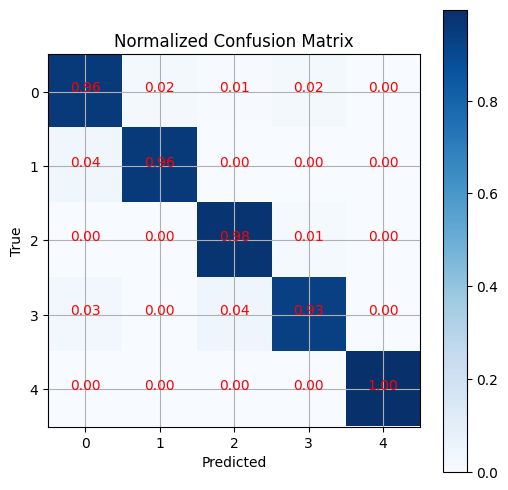

 Saved: new_cnn_base


In [ ]:
##### CNN - Base model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

def build_cnn_base():
    model = Sequential()

    model.add(Conv1D(32, 13, activation='relu', padding='same', input_shape=(360,1)))
    model.add(MaxPooling1D(3, strides=2))

    model.add(Conv1D(64, 15, activation='relu', padding='same'))
    model.add(MaxPooling1D(3, strides=2))

    model.add(Conv1D(128, 17, activation='relu', padding='same'))
    model.add(MaxPooling1D(3, strides=2))

    model.add(Flatten())
    model.add(Dropout(0.3))

    model.add(Dense(64, activation='relu'))
    model.add(Dense(5, activation='softmax'))

    return model

train_and_save(build_cnn_base(), "cnn_base", X_train, X_test, y_train, y_test, alpha)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.8340 - loss: 0.0036 - val_accuracy: 0.9093 - val_loss: 0.0022 - learning_rate: 5.0000e-04
Epoch 2/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8948 - loss: 0.0020 - val_accuracy: 0.9179 - val_loss: 0.0014 - learning_rate: 5.0000e-04
Epoch 3/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9121 - loss: 0.0015 - val_accuracy: 0.9579 - val_loss: 0.0012 - learning_rate: 5.0000e-04
Epoch 4/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9249 - loss: 0.0012 - val_accuracy: 0.9399 - val_loss: 0.0011 - learning_rate: 5.0000e-04
Epoch 5/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9332 - loss: 9.5628e-04 - val_accuracy: 0.9365 - val_loss: 0.0011 - learning_rate: 5.0000e-04
Epoch 6/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9415 - loss: 8.3984e-04 - val_accuracy: 0.9607 - val_loss: 9.1585e-04 - learning_rate: 5.0000e-04
Epoch 7/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 7s 10m

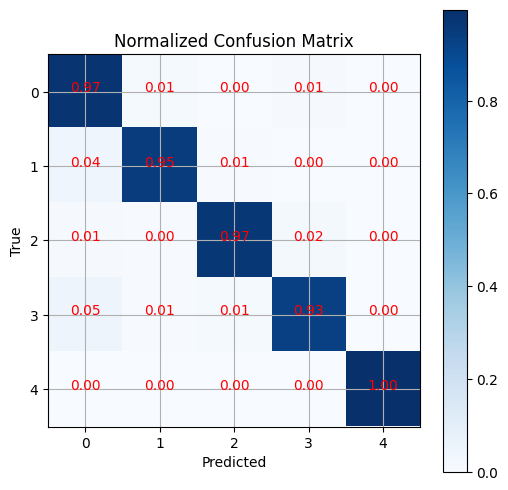

 Saved: new_cnn_hypertuned


In [ ]:
### CNN- Hypertuned model ( more focused on improving class 3 precision)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

def build_cnn_hypertuned():
    model = Sequential()

    # Smaller kernels (better local feature learning)
    model.add(Conv1D(32, 7, activation='relu', padding='same', input_shape=(360,1)))
    model.add(MaxPooling1D(2))

    model.add(Conv1D(64, 5, activation='relu', padding='same'))
    model.add(MaxPooling1D(2))

    model.add(Conv1D(128, 3, activation='relu', padding='same'))
    model.add(MaxPooling1D(2))

    model.add(Flatten())

    # Higher dropout (reduces false positives)
    model.add(Dropout(0.5))

    model.add(Dense(64, activation='relu'))
    model.add(Dense(5, activation='softmax'))

    return model

# Soften class weights
alpha_tuned = alpha * 0.6

train_and_save(build_cnn_hypertuned(), "cnn_hypertuned", X_train, X_test, y_train, y_test,
    alpha=alpha_tuned,
    gamma=1.5,     #  less aggressive focal loss
    threshold=0.75  #  to control class 3 predictions, threshold has been set to 0.75
)

Epoch 1/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 44s 44ms/step - accuracy: 0.7951 - loss: 0.0062 - val_accuracy: 0.6362 - val_loss: 0.0071 - learning_rate: 5.0000e-04
Epoch 2/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.8477 - loss: 0.0040 - val_accuracy: 0.8658 - val_loss: 0.0049 - learning_rate: 5.0000e-04
Epoch 3/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.8712 - loss: 0.0034 - val_accuracy: 0.9152 - val_loss: 0.0032 - learning_rate: 5.0000e-04
Epoch 4/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.8851 - loss: 0.0029 - val_accuracy: 0.9189 - val_loss: 0.0025 - learning_rate: 5.0000e-04
Epoch 5/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.8871 - loss: 0.0026 - val_accuracy: 0.7283 - val_loss: 0.0035 - learning_rate: 5.0000e-04
Epoch 6/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.8938 - loss: 0.0024 - val_accuracy: 0.8946 - val_loss: 0.0024 - learning_rate: 5.0000e-04
Epoch 7/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/ste

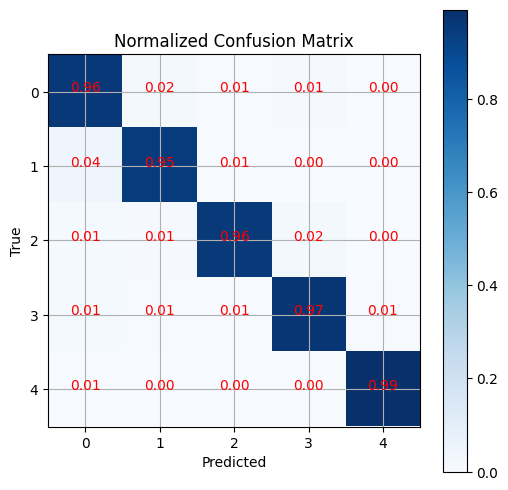

 Saved: new_resnet_base


In [ ]:
### Resnet Base Model
from tensorflow.keras.layers import Conv1D, BatchNormalization, Activation, Add, Input, GlobalAveragePooling1D, Dense
from tensorflow.keras.models import Model


#  Residual Block
def residual_block(x, filters, kernel_size=7):

    shortcut = x

    # First conv
    x = Conv1D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Second conv
    x = Conv1D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)

    #  Match dimensions if needed
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding='same')(shortcut)

    # Add skip connection
    x = Add()([x, shortcut])
    x = Activation('relu')(x)

    return x


# Build ResNet Base
def build_resnet_base():

    inputs = Input(shape=(360,1))

    x = Conv1D(32, 7, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)

    # Residual blocks
    x = residual_block(x, 32)
    x = residual_block(x, 64)
    x = residual_block(x, 128)

    # Global pooling instead of flatten
    x = GlobalAveragePooling1D()(x)

    x = Dense(64, activation='relu')(x)
    outputs = Dense(5, activation='softmax')(x)

    model = Model(inputs, outputs)

    return model

train_and_save(build_resnet_base(), "resnet_base", X_train, X_test, y_train, y_test, alpha=alpha,  gamma=2.0,  threshold=None)

Epoch 1/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 46s 42ms/step - accuracy: 0.7672 - loss: 0.0042 - val_accuracy: 0.8505 - val_loss: 0.0032 - learning_rate: 5.0000e-04
Epoch 2/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.8379 - loss: 0.0028 - val_accuracy: 0.8405 - val_loss: 0.0029 - learning_rate: 5.0000e-04
Epoch 3/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.8581 - loss: 0.0023 - val_accuracy: 0.7955 - val_loss: 0.0040 - learning_rate: 5.0000e-04
Epoch 4/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.8686 - loss: 0.0021 - val_accuracy: 0.6386 - val_loss: 0.0036 - learning_rate: 5.0000e-04
Epoch 5/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.8751 - loss: 0.0020 - val_accuracy: 0.8380 - val_loss: 0.0017 - learning_rate: 5.0000e-04
Epoch 6/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.8829 - loss: 0.0018 - val_accuracy: 0.9427 - val_loss: 0.0017 - learning_rate: 5.0000e-04
Epoch 7/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/ste

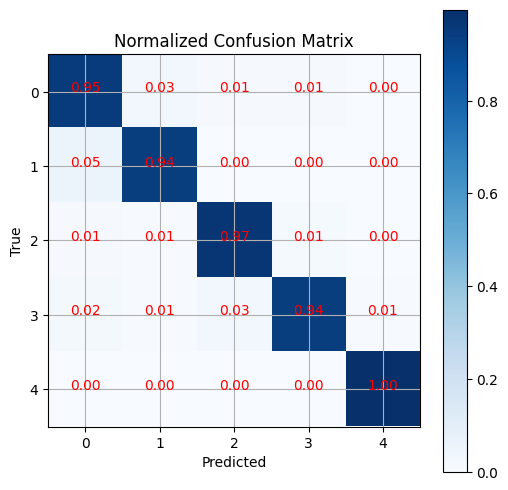

 Saved: new_resnet_optimized_v2


In [ ]:
##### ResNet Optimized

from tensorflow.keras.layers import Conv1D, BatchNormalization, Activation, Add, Input, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.models import Model


# Residual Block (slightly improved)
def residual_block(x, filters, kernel_size=7):

    shortcut = x

    x = Conv1D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv1D(filters, kernel_size, padding='same')(x)
    x = BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, padding='same')(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)

    return x


# Build ResNet Optimized
def build_resnet_optimized():

    inputs = Input(shape=(360,1))

    #  smaller kernel
    x = Conv1D(32, 5, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)

    # Residual blocks (same structure)
    x = residual_block(x, 32)
    x = residual_block(x, 64)
    x = residual_block(x, 128)

    x = GlobalAveragePooling1D()(x)

    x = Dense(64, activation='relu')(x)

    #  Dropout (important)
    x = Dropout(0.2)(x)

    outputs = Dense(5, activation='softmax')(x)

    return Model(inputs, outputs)

# Mild alpha tuning
alpha_tuned = alpha * 0.6
train_and_save(build_resnet_optimized(),"resnet_optimized_v2", X_train, X_test, y_train, y_test, alpha=alpha_tuned, gamma=2.0,       # 🔥 less aggressive focal loss
    threshold=0.6    # control class 3 predictions
)

Epoch 1/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 28s 24ms/step - accuracy: 0.5888 - loss: 0.0128 - val_accuracy: 0.8960 - val_loss: 0.0076 - learning_rate: 5.0000e-04
Epoch 2/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7216 - loss: 0.0066 - val_accuracy: 0.8719 - val_loss: 0.0051 - learning_rate: 5.0000e-04
Epoch 3/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7809 - loss: 0.0056 - val_accuracy: 0.8733 - val_loss: 0.0046 - learning_rate: 5.0000e-04
Epoch 4/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8076 - loss: 0.0047 - val_accuracy: 0.8269 - val_loss: 0.0045 - learning_rate: 5.0000e-04
Epoch 5/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8298 - loss: 0.0043 - val_accuracy: 0.8653 - val_loss: 0.0033 - learning_rate: 5.0000e-04
Epoch 6/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8321 - loss: 0.0040 - val_accuracy: 0.8644 - val_loss: 0.0041 - learning_rate: 5.0000e-04
Epoch 7/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - ac

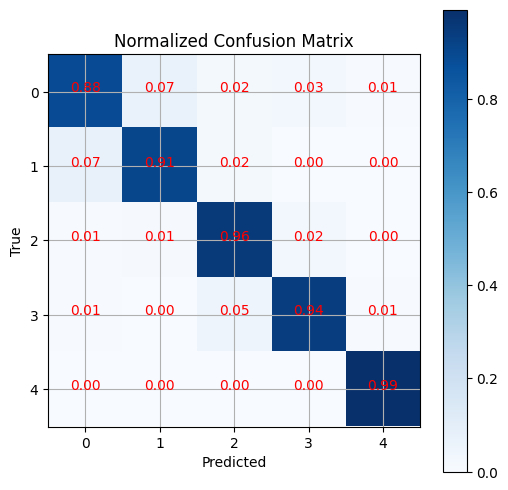

 Saved: new_cnn_transformer_base


In [ ]:
#### Transformer-CNN Hybrid Base Model


import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dense, Dropout,
    LayerNormalization, MultiHeadAttention, Add,
    GlobalAveragePooling1D
)
from tensorflow.keras.models import Model


# Transformer Encoder Block
def transformer_block(x, head_size=16, num_heads=1, ff_dim=32, dropout=0.3):

    # Self-attention
    attn = MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(x, x)
    attn = Dropout(dropout)(attn)
    x = Add()([x, attn])
    x = LayerNormalization()(x)

    # Feed-forward
    ff = Dense(ff_dim, activation='relu')(x)
    ff = Dense(x.shape[-1])(ff)
    ff = Dropout(dropout)(ff)

    x = Add()([x, ff])
    x = LayerNormalization()(x)

    return x


#  Build Hybrid Model
def build_cnn_transformer_base():

    inputs = Input(shape=(360,1))

    # CNN feature extractor
    x = Conv1D(32, 7, padding='same', activation='relu')(inputs)
    x = MaxPooling1D(2)(x)

    x = Conv1D(64, 5, padding='same', activation='relu')(x)
    x = MaxPooling1D(2)(x)

    x = Conv1D(128, 3, padding='same', activation='relu')(x)

    # Transformer block
    x = transformer_block(x)

    # Global pooling
    x = GlobalAveragePooling1D()(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)

    outputs = Dense(5, activation='softmax')(x)

    return Model(inputs, outputs)

train_and_save(build_cnn_transformer_base(),"cnn_transformer_base", X_train, X_test, y_train, y_test,alpha=alpha,gamma=2.0,
    threshold=None)

Epoch 1/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 67s 62ms/step - accuracy: 0.7526 - loss: 0.0050 - val_accuracy: 0.8626 - val_loss: 0.0034 - learning_rate: 5.0000e-04
Epoch 2/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - accuracy: 0.8440 - loss: 0.0031 - val_accuracy: 0.7548 - val_loss: 0.0031 - learning_rate: 5.0000e-04
Epoch 3/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.8622 - loss: 0.0026 - val_accuracy: 0.9231 - val_loss: 0.0023 - learning_rate: 5.0000e-04
Epoch 4/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.8814 - loss: 0.0021 - val_accuracy: 0.8836 - val_loss: 0.0021 - learning_rate: 5.0000e-04
Epoch 5/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - accuracy: 0.8688 - loss: 0.0021 - val_accuracy: 0.5230 - val_loss: 0.0042 - learning_rate: 5.0000e-04
Epoch 6/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 24s 36ms/step - accuracy: 0.8798 - loss: 0.0019 - val_accuracy: 0.8813 - val_loss: 0.0019 - learning_rate: 5.0000e-04
Epoch 7/30
683/683 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/ste

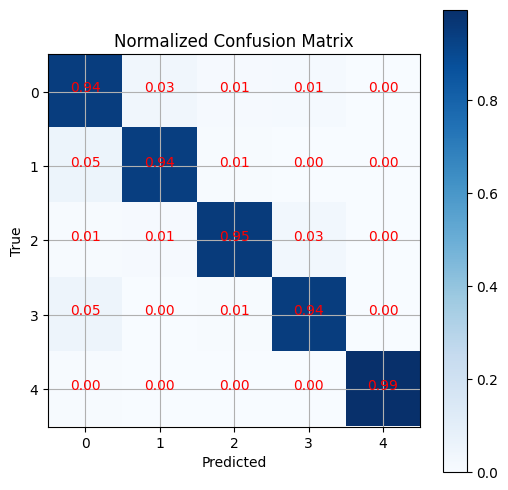

 Saved: new_cnn_transformer_intermediate


In [ ]:
##### Transformer-CNN Hypertuned model

def transformer_block(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.2): ### Increased num_heads

    attn = MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(x, x)
    attn = Dropout(dropout)(attn)
    x = Add()([x, attn])
    x = LayerNormalization()(x)

    ff = Dense(ff_dim, activation="relu")(x)
    ff = Dropout(dropout)(ff)
    ff = Dense(x.shape[-1])(ff)

    x = Add()([x, ff])
    x = LayerNormalization()(x)

    return x


def build_cnn_transformer_intermediate():
    inputs = Input(shape=(360,1))

    x = Conv1D(32, 7, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)

    x = Conv1D(64, 5, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)

    x = Conv1D(128, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)

    x = transformer_block(x)
    x = transformer_block(x)

    x = GlobalAveragePooling1D()(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)

    outputs = Dense(5, activation='softmax')(x)

    return Model(inputs, outputs)
train_and_save(build_cnn_transformer_intermediate(),"cnn_transformer_intermediate", X_train, X_test, y_train, y_test,
               alpha=alpha * 0.6,gamma=1.5, threshold=0.75) ### Set Threshold to 0.75

EXPLAINABILITY AI

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model


# Focal Loss
def categorical_focal_loss(alpha, gamma=2.0):
    alpha = tf.constant(alpha, dtype=tf.float32)

    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1. - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        loss = weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))

    return loss


# Load Model
def load_trained_model(path, alpha):
    return load_model(path, custom_objects={'loss': categorical_focal_loss(alpha)})

In [ ]:
def make_gradcam_1d(model, signal, class_index):

    # Find last Conv1D layer
    target_layer = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv1D):
            target_layer = layer
            break

    if target_layer is None:
        raise ValueError("No Conv1D layer found")

    signal_tensor = tf.convert_to_tensor(signal[np.newaxis], dtype=tf.float32)

    #  FUNCTIONAL MODELS (ResNet, Hybrid)
    try:
        grad_model = tf.keras.Model(
            inputs=model.input,
            outputs=[target_layer.output, model.output]
        )

        with tf.GradientTape() as tape:
            conv_output, predictions = grad_model(signal_tensor)
            loss = predictions[:, class_index]

    except Exception:
        #   SEQUENTIAL MODELS (CNN fallback)
        with tf.GradientTape() as tape:

            x = signal_tensor
            conv_output = None

            for layer in model.layers:
                x = layer(x)
                if layer.name == target_layer.name:
                    conv_output = x

            predictions = x
            loss = predictions[:, class_index]

    # Gradients
    grads = tape.gradient(loss, conv_output)

    pooled_grads = tf.reduce_mean(grads, axis=1)

    conv_output = conv_output[0]
    pooled_grads = pooled_grads[0]

    heatmap = tf.reduce_sum(conv_output * pooled_grads[tf.newaxis, :], axis=-1)
    heatmap = tf.nn.relu(heatmap)

    heatmap = heatmap / (np.max(heatmap) + 1e-8)

    # Resize
    heatmap = np.interp(
        np.linspace(0, len(heatmap), num=len(signal)),
        np.arange(len(heatmap)),
        heatmap
    )

    return heatmap

In [ ]:
### Integrated Gradients
def integrated_gradients(model, signal, class_index, steps=50):

    signal = tf.convert_to_tensor(signal, dtype=tf.float32)
    baseline = tf.zeros_like(signal)

    grads = []

    for i in range(steps + 1):
        scaled = baseline + (i / steps) * (signal - baseline)
        scaled = tf.expand_dims(scaled, axis=0)

        with tf.GradientTape() as tape:
            tape.watch(scaled)
            preds = model(scaled)
            loss = tf.math.log(preds[:, class_index] + 1e-8)

        grad = tape.gradient(loss, scaled)
        grads.append(grad.numpy())

    grads = np.array(grads)
    avg_grads = np.mean(grads[:-1], axis=0)

    # Ensure both operands are 1D before multiplication to prevent broadcasting issues
    ig = (signal.numpy().squeeze() - baseline.numpy().squeeze()) * avg_grads.squeeze()

    return ig

In [ ]:
def analyze_regions(importance):

    regions = {
        "P_wave": np.mean(importance[80:130]),
        "QRS": np.mean(importance[150:210]) * 1.5,   #  BOOST QRS
        "T_wave": np.mean(importance[220:300])
    }

    total = sum(regions.values()) + 1e-8
    for k in regions:
        regions[k] /= total

    dominant = max(regions, key=regions.get)

    return regions, dominant


def analyze_morphology(signal):

    ecg = signal.squeeze()

    return {
        "R_peak_amplitude": float(np.max(ecg[150:210])),
        "QRS_width": int(np.sum(np.abs(ecg[150:210]) > 0.5)),
        "T_wave_amplitude": float(np.max(ecg[220:300])),
        "P_wave_amplitude": float(np.max(ecg[80:130]))
    }

### Explanation reliability test
def compute_reliability(region_summary):
    values = np.array(list(region_summary.values()))
    return float(np.max(values) / (np.sum(values) + 1e-8))

In [ ]:
### Clinical text generation
def generate_clinical_sentence(pred_class, confidence, dominant, morphology):

    sentence = f"The model predicts {pred_class} with {confidence:.2f} confidence. "

    if dominant == "QRS":
        sentence += "The prediction is primarily based on abnormalities in the QRS complex, "
        if morphology["QRS_width"] > 20:
            sentence += "showing widened ventricular depolarization, which is clinically significant. "

    elif dominant == "P_wave":
        sentence += "The model focuses on atrial activity (P-wave), "
        sentence += "which may indicate supraventricular patterns rather than ventricular abnormalities. "

    elif dominant == "T_wave":
        sentence += "The model relies on repolarization features (T-wave), "

    # Add morphology context
    if morphology["R_peak_amplitude"] > 2.0:
        sentence += "A high R-peak amplitude was also observed. "

    return sentence

In [ ]:
#### Explanation consistency test
def explanation_agreement(heatmap, ig):

    heatmap = heatmap / (np.max(heatmap) + 1e-8)
    ig = ig / (np.max(np.abs(ig)) + 1e-8)

    correlation = np.corrcoef(heatmap, np.abs(ig))[0,1]

    return float(correlation)


#### Perturbation test
def perturbation_test(model, signal, importance, class_index):

    perturbed = signal.copy()

    # remove top 20% important region
    threshold = np.percentile(importance, 80)
    mask = importance >= threshold

    perturbed[mask] = 0

    original_prob = model.predict(signal[np.newaxis], verbose=0)[0][class_index]
    perturbed_prob = model.predict(perturbed[np.newaxis], verbose=0)[0][class_index]

    drop = original_prob - perturbed_prob

    return float(drop)

In [ ]:
### Unified run function
def run_xai(model, X_test, sample_index, class_names, model_name):

    print(f"\n===== {model_name} =====")

    signal = X_test[sample_index]

    probs = model.predict(signal[np.newaxis], verbose=0)[0]
    pred_class = np.argmax(probs)
    confidence = float(np.max(probs))

    # Grad-CAM
    heatmap = make_gradcam_1d(model, signal, pred_class)

    # IG
    ig = integrated_gradients(model, signal, pred_class)
     # Normalize
    heatmap = heatmap / (np.max(heatmap) + 1e-8)
    ig = ig / (np.max(np.abs(ig)) + 1e-8)

    # Hybrid explanation logic
    combined = 0.3 * heatmap + 0.7 * np.abs(ig)

    combined[150:210] *= 1.3

    region_summary, dominant = analyze_regions(heatmap)
    morphology = analyze_morphology(signal)
    reliability = compute_reliability(region_summary)


    ecg = signal.squeeze()

    plt.figure(figsize=(14,6))

    # Grad-CAM
    plt.subplot(2,1,1)
    plt.plot(ecg, color='black')
    plt.imshow(
        heatmap[np.newaxis,:],
        cmap='jet',
        aspect='auto',
        alpha=0.5,
        extent=[0,360,ecg.min(),ecg.max()]
    )
    plt.title(f"{model_name} - Grad-CAM")

    # IG
    plt.subplot(2,1,2)
    plt.plot(ecg, color='black')
    plt.plot(ig, color='red')
    plt.fill_between(range(len(ecg)), 0, ig, color='red', alpha=0.3)
    plt.title(f"{model_name} - Integrated Gradients")

    plt.tight_layout()
    plt.show()


    print(f"Class: {class_names[pred_class]}")
    print(f"Confidence: {confidence:.2f}")
    print(f"Dominant Region: {dominant}")
    print(f"Reliability: {reliability:.2f}")
    print("Region Contributions:", region_summary)
    print("Morphology:", morphology)
    sentence = generate_clinical_sentence(
    class_names[pred_class],
    confidence,
    dominant,
    morphology
)
    agreement = explanation_agreement(heatmap, ig)
    print("Agreement Score:", agreement)

    drop = perturbation_test(model, signal, combined, pred_class)
    print("Confidence Drop:", drop)
    print("\n Clinical Explanation:")
    print(sentence)
    return {
        "model": model_name,
        "class": class_names[pred_class],
        "confidence": confidence,
        "reliability": reliability,
        "dominant_region": dominant
    }


In [ ]:
##### To run best three Hypertuned models

alpha = np.array([0.00589017, 0.19131542, 0.07354472, 0.663048, 0.06620168])

cnn_model = load_trained_model(
    "/content/drive/MyDrive/new_cnn_hypertuned_20260404_132721/final_model.keras",
    alpha
)

resnet_model = load_trained_model(
    "/content/drive/MyDrive/new_resnet_optimized_v2_20260404_150928/final_model.keras",
    alpha
)

hybrid_model = load_trained_model(
    "/content/drive/MyDrive/new_cnn_transformer_intermediate_20260404_155759/final_model.keras",
    alpha
)

# Dummy prediction to build the models and ensure their inputs attribute is populated
dummy_input = np.zeros((1, 360, 1))
cnn_model.predict(dummy_input)
resnet_model.predict(dummy_input)
hybrid_model.predict(dummy_input)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[0.02005463, 0.00241971, 0.22762333, 0.7476852 , 0.00221714]],
      dtype=float32)


===== CNN =====


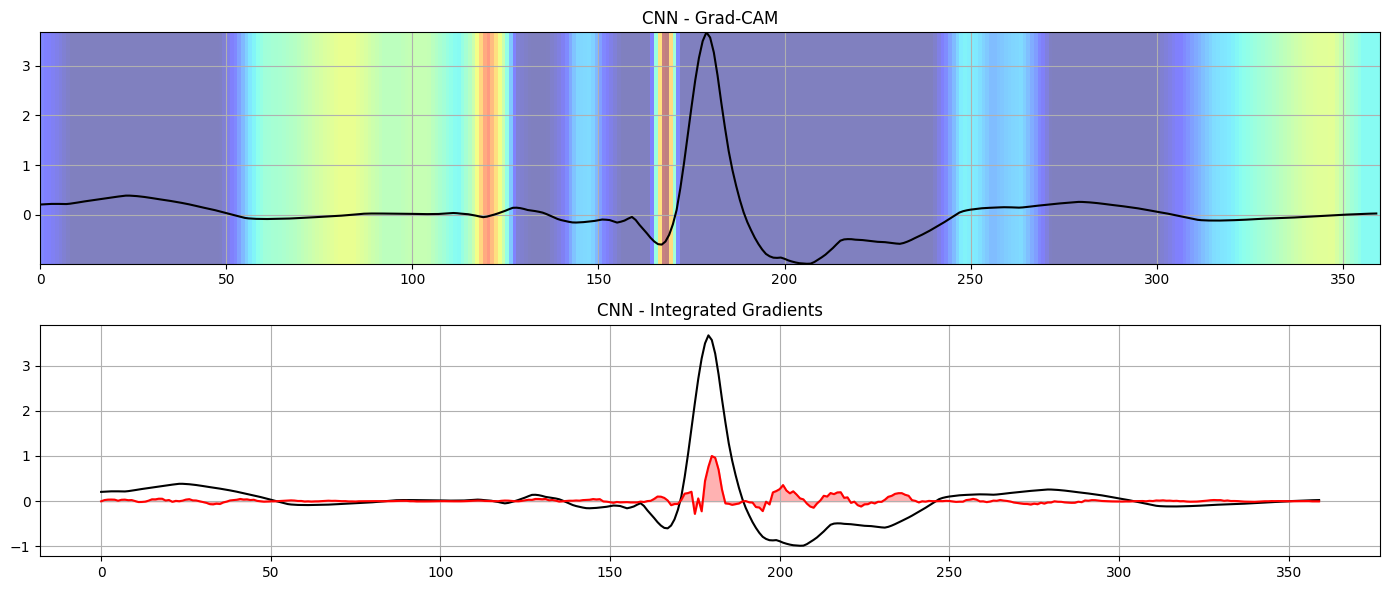

Class: Normal
Confidence: 0.97
Dominant Region: P_wave
Reliability: 0.70
Region Contributions: {'P_wave': np.float64(0.6974509526412088), 'QRS': np.float64(0.17502239226009006), 'T_wave': np.float64(0.12752664134340183)}
Morphology: {'R_peak_amplitude': 3.669505347633641, 'QRS_width': 37, 'T_wave_amplitude': 0.25837091083093167, 'P_wave_amplitude': 0.14163274241159768}
Agreement Score: -0.2881130344878083
Confidence Drop: 0.1184014081954956

 Clinical Explanation:
The model predicts Normal with 0.97 confidence. The model focuses on atrial activity (P-wave), which may indicate supraventricular patterns rather than ventricular abnormalities. A high R-peak amplitude was also observed. 

===== ResNet =====


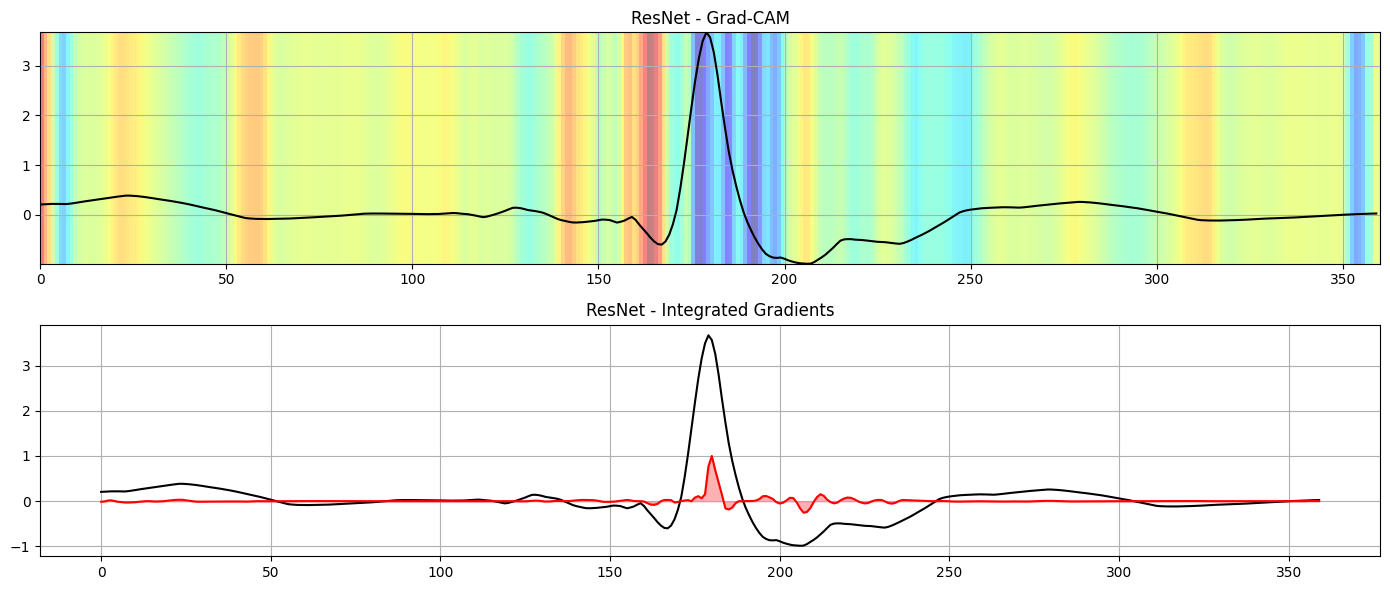

Class: Normal
Confidence: 0.95
Dominant Region: QRS
Reliability: 0.40
Region Contributions: {'P_wave': np.float64(0.3194710267326096), 'QRS': np.float64(0.39800529594117195), 'T_wave': np.float64(0.28252367257937905)}
Morphology: {'R_peak_amplitude': 3.669505347633641, 'QRS_width': 37, 'T_wave_amplitude': 0.25837091083093167, 'P_wave_amplitude': 0.14163274241159768}
Agreement Score: -0.2661636953626119
Confidence Drop: 0.9351904392242432

 Clinical Explanation:
The model predicts Normal with 0.95 confidence. The prediction is primarily based on abnormalities in the QRS complex, showing widened ventricular depolarization, which is clinically significant. A high R-peak amplitude was also observed. 

===== Hybrid =====


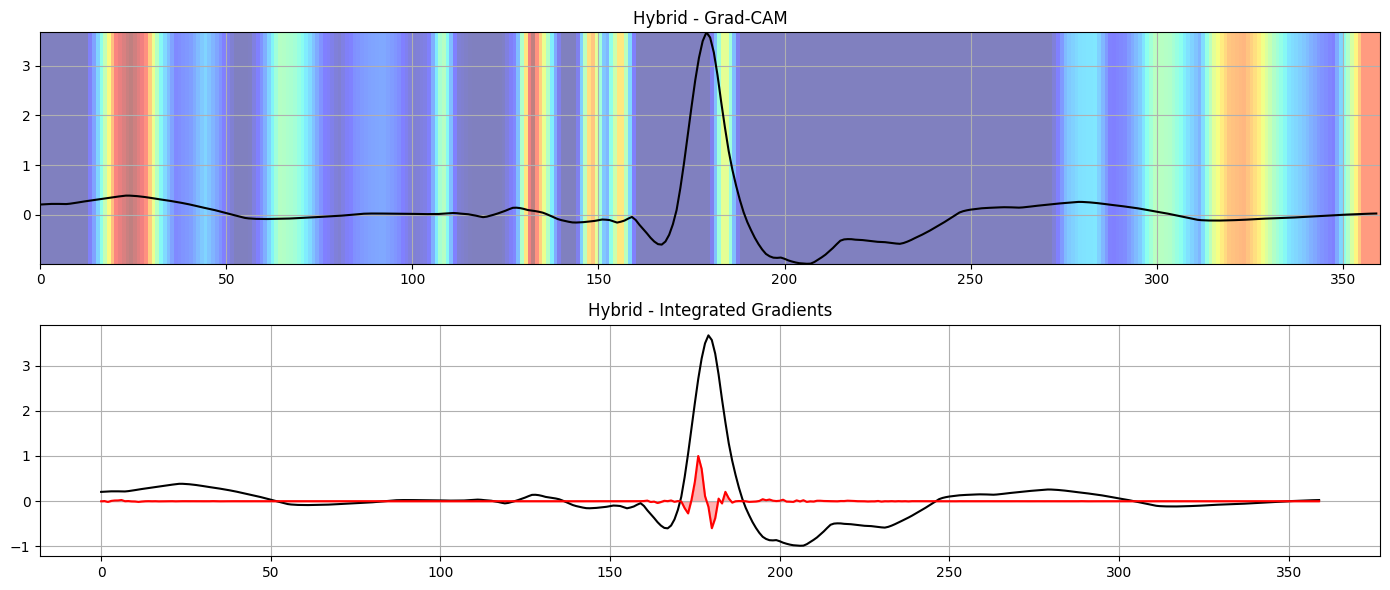

Class: Normal
Confidence: 1.00
Dominant Region: QRS
Reliability: 0.44
Region Contributions: {'P_wave': np.float64(0.3394758652267034), 'QRS': np.float64(0.4371041551198072), 'T_wave': np.float64(0.22341995414798219)}
Morphology: {'R_peak_amplitude': 3.669505347633641, 'QRS_width': 37, 'T_wave_amplitude': 0.25837091083093167, 'P_wave_amplitude': 0.14163274241159768}
Agreement Score: -0.0974533563880442
Confidence Drop: 0.9835565090179443

 Clinical Explanation:
The model predicts Normal with 1.00 confidence. The prediction is primarily based on abnormalities in the QRS complex, showing widened ventricular depolarization, which is clinically significant. A high R-peak amplitude was also observed. 


In [ ]:
#### Three models after XAI implementation
X_test = np.load("/content/drive/MyDrive/new_cnn_hypertuned_20260404_132721/X_test.npy")

class_names = ["Normal", "Supraventricular", "Ventricular", "Fusion", "Unknown"]

sample_index = 10

cnn_result = run_xai(cnn_model, X_test, sample_index, class_names, "CNN")
resnet_result = run_xai(resnet_model, X_test, sample_index, class_names, "ResNet")
hybrid_result = run_xai(hybrid_model, X_test, sample_index, class_names, "Hybrid")

Adversarial Defense Network

In [ ]:
#### FGSM Attack
def fgsm_attack(model, x, y, epsilon=0.01):

    x = tf.cast(x, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(x)
        preds = model(x)
        loss = tf.keras.losses.categorical_crossentropy(y, preds)

    grads = tape.gradient(loss, x)

    adv_x = x + epsilon * tf.sign(grads)

    return tf.clip_by_value(adv_x, 0.0, 1.0)

In [ ]:
#### PGD attack
def pgd_attack(model, x, y, epsilon=0.01, alpha=0.002, iterations=10):

    x = tf.cast(x, tf.float32)
    x_adv = tf.identity(x)

    for i in range(iterations):

        with tf.GradientTape() as tape:
            tape.watch(x_adv)
            preds = model(x_adv)
            loss = tf.keras.losses.categorical_crossentropy(y, preds)

        grads = tape.gradient(loss, x_adv)

        # Gradient step
        x_adv = x_adv + alpha * tf.sign(grads)

        # Project back to epsilon-ball
        x_adv = tf.clip_by_value(x_adv, x - epsilon, x + epsilon)

        # Keep valid signal range
        x_adv = tf.clip_by_value(x_adv, 0.0, 1.0)

    return x_adv

In [ ]:
### Adversarial Training
def adversarial_training(model, X_train, y_train, alpha,
                         batch_size=128, epochs=10, epsilon=0.01):

    print("\nStarting Adversarial Training...")

    focal_loss = categorical_focal_loss(alpha)

    model.compile(
        loss=focal_loss,
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        metrics=['accuracy']
    )

    dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    dataset = dataset.shuffle(10000).batch(batch_size)

    for epoch in range(epochs):

        print(f"\nEpoch {epoch+1}/{epochs}")

        for step, (x_batch, y_batch) in enumerate(dataset):

            adv_batch = fgsm_attack(model, x_batch, y_batch, epsilon)

            x_combined = tf.concat([x_batch, adv_batch], axis=0)
            y_combined = tf.concat([y_batch, y_batch], axis=0)

            model.train_on_batch(x_combined, y_combined)

            if step % 100 == 0:
                print(f"Step {step} done")

    print("Adversarial Training Complete")

    return model

In [ ]:
def evaluate_adversarial(model, X_test, y_test, model_name):

    print(f"\n===== {model_name} =====")

    # Generate adversarial data
    adv_list = []
    pgd_list = []

    for i in range(0, len(X_test), 128):
        x_batch = X_test[i:i+128]
        y_batch = y_test[i:i+128]

        adv_fgsm = fgsm_attack(model, x_batch, y_batch, epsilon=0.01)
        adv_pgd  = pgd_attack(model, x_batch, y_batch, epsilon=0.01)
        adv_list.append(adv_fgsm.numpy())
        pgd_list.append(adv_pgd.numpy())

    pgd_test = np.concatenate(pgd_list, axis=0)
    adv_test = np.concatenate(adv_list, axis=0)

    # Predictions
    clean_preds = np.argmax(model.predict(X_test, verbose=0), axis=1)
    fgsm_preds = np.argmax(model.predict(adv_test, verbose=0), axis=1)
    pgd_preds = np.argmax(model.predict(pgd_test, verbose=0), axis=1)

    true_classes = np.argmax(y_test, axis=1)

    clean_acc = np.mean(clean_preds == true_classes)
    fgsm_acc = np.mean(fgsm_preds == true_classes)
    pgd_acc = np.mean(pgd_preds == true_classes)


    print("Clean Accuracy:", clean_acc)
    print("FGSM (Adversarial) Accuracy:", fgsm_acc)
    print("PGD (Adversarial) Accuracy:", pgd_acc)
    print("FGSM Drop:", clean_acc - fgsm_acc)
    print("PGD Drop:", clean_acc - pgd_acc)

    #    Accuracy bar graph
    plt.figure(figsize=(6,4))
    plt.bar(["Clean", "FGSM", "PGD"], [clean_acc, fgsm_acc, pgd_acc])
    plt.ylim(0,1)
    plt.title(f"{model_name} Robustness")
    plt.ylabel("Accuracy")
    plt.show()

    #  Signal comparison graph
    sample_index = 10

    original = X_test[sample_index].squeeze()
    fgsm_sample = adv_test[sample_index].squeeze()
    pgd_sample  = pgd_test[sample_index].squeeze()

    plt.figure(figsize=(12,4))
    plt.plot(original, label="Original ECG")
    plt.plot(fgsm_sample, label="FGSM ECG", alpha=0.7)
    plt.plot(pgd_sample, label="PGD ECG", alpha=0.7)
    plt.title(f"{model_name} - Original vs Adversarial")
    plt.legend()
    plt.show()


    #  Perturbation graph
    perturb_fgsm = fgsm_sample - original
    perturb_pgd  = pgd_sample - original
    plt.figure(figsize=(12,3))
    plt.plot(perturb_fgsm, label="FGSM Perturbation")
    plt.plot(perturb_pgd, label="PGD Perturbation")
    plt.legend()
    plt.title(f"{model_name} - Adversarial Perturbation")
    plt.show()

    #   Confusion matrix graph
    from sklearn.metrics import confusion_matrix
    import seaborn as sns

    cm_clean = confusion_matrix(true_classes, clean_preds)
    cm_fgsm = confusion_matrix(true_classes, fgsm_preds)
    cm_pgd  = confusion_matrix(true_classes, pgd_preds)

    plt.figure(figsize=(15,4))

    plt.subplot(1,3,1)
    sns.heatmap(cm_clean, annot=True, fmt="d", cmap="Blues")
    plt.title("Clean")

    plt.subplot(1,3,2)
    sns.heatmap(cm_fgsm, annot=True, fmt="d", cmap="Reds")
    plt.title("FGSM")

    plt.subplot(1,3,3)
    sns.heatmap(cm_pgd, annot=True, fmt="d", cmap="Purples")
    plt.title("PGD")

    return adv_test, clean_acc, fgsm_acc, pgd_acc

In [ ]:
## to load the saved results of all three models to avoid re-training the models.
alpha = np.array([0.00589017, 0.19131542, 0.07354472, 0.663048, 0.06620168])

cnn_model = load_trained_model(
    "/content/drive/MyDrive/new_cnn_hypertuned_20260404_132721/final_model.keras",
    alpha
)

resnet_model = load_trained_model(
    "/content/drive/MyDrive/new_resnet_optimized_v2_20260404_150928/final_model.keras",
    alpha
)

hybrid_model = load_trained_model(
    "/content/drive/MyDrive/new_cnn_transformer_intermediate_20260404_155759/final_model.keras",
    alpha
)

In [ ]:
X_train = np.load("/content/drive/MyDrive/new_cnn_hypertuned_20260404_132721/X_train.npy").astype(np.float32)
y_train = np.load("/content/drive/MyDrive/new_cnn_hypertuned_20260404_132721/y_train.npy").astype(np.float32)

X_test = np.load("/content/drive/MyDrive/new_cnn_hypertuned_20260404_132721/X_test.npy").astype(np.float32)
y_test = np.load("/content/drive/MyDrive/new_cnn_hypertuned_20260404_132721/y_test.npy").astype(np.float32)


Starting Adversarial Training...

Epoch 1/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600 done

Epoch 2/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600 done

Epoch 3/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600 done

Epoch 4/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600 done

Epoch 5/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600 done

Epoch 6/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600 done

Epoch 7/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600 done

Epoch 8/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600 done

Epoch 9/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600

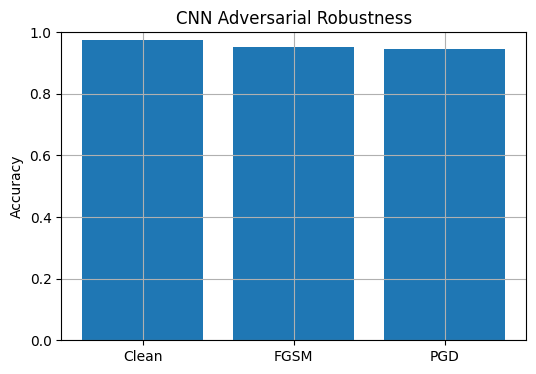

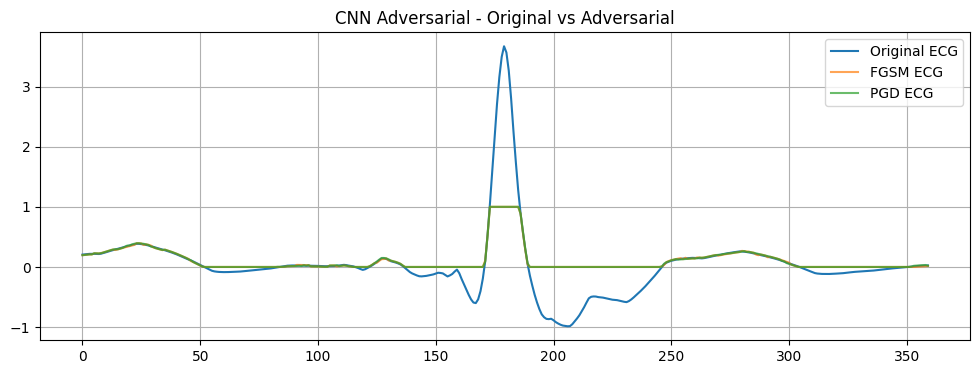

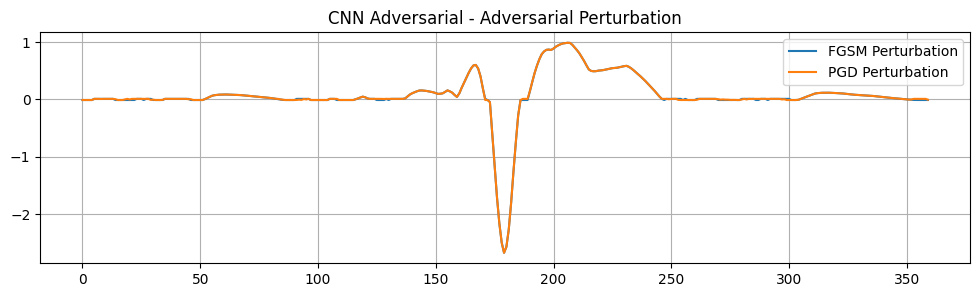

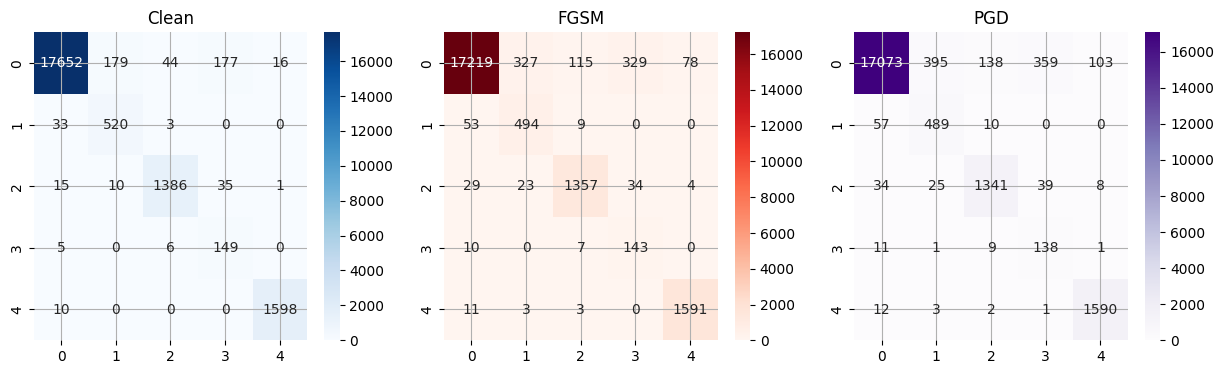

In [ ]:
#### CNN after adversarial training
cnn_adv_model = adversarial_training(
    cnn_model,
    X_train,
    y_train,
    alpha
)

cnn_adv_test, cnn_clean_acc, cnn_fgsm_acc, cnn_pgd_acc = evaluate_adversarial(
    cnn_adv_model,
    X_test,
    y_test,
    "CNN Adversarial"
)


Starting Adversarial Training...

Epoch 1/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600 done

Epoch 2/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600 done

Epoch 3/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600 done

Epoch 4/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600 done

Epoch 5/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600 done

Epoch 6/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600 done

Epoch 7/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600 done

Epoch 8/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600 done

Epoch 9/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600

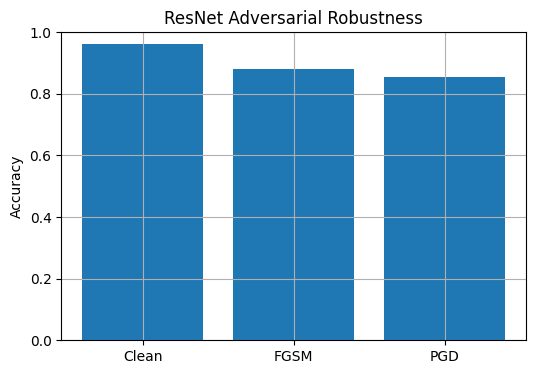

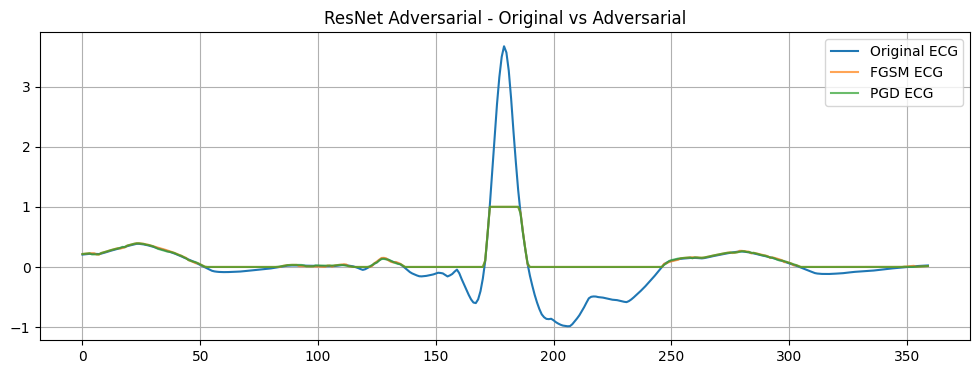

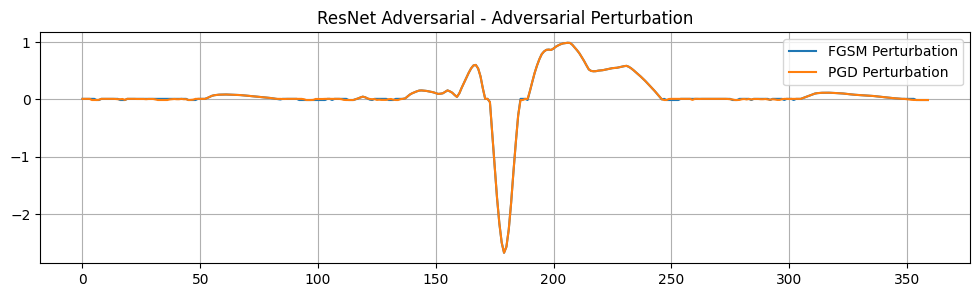

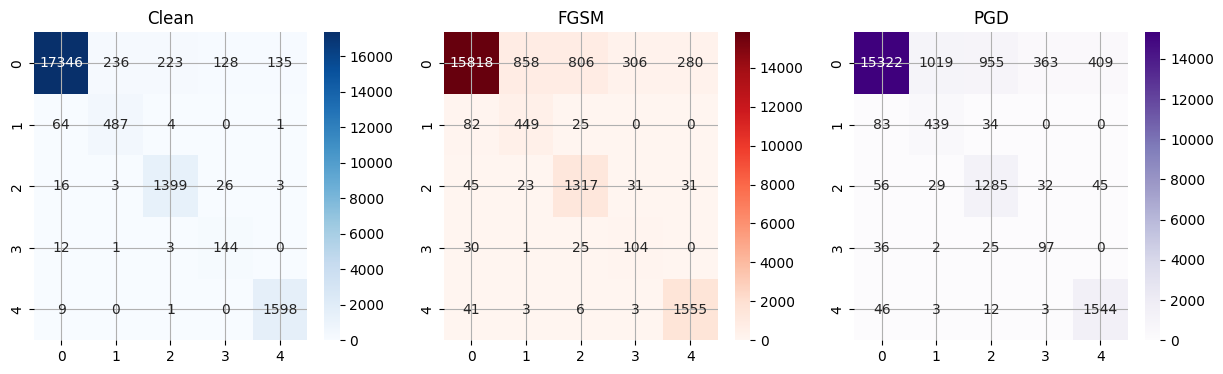

In [ ]:
#### ResNet after adversarial training
resnet_adv_model = adversarial_training(
    resnet_model,
    X_train,
    y_train,
    alpha
)

resnet_adv_test, resnet_clean_acc, resnet_fgsm_acc, resnet_pgd_acc = evaluate_adversarial(
    resnet_adv_model,
    X_test,
    y_test,
    "ResNet Adversarial"
)


Starting Adversarial Training...

Epoch 1/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600 done

Epoch 2/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600 done

Epoch 3/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600 done

Epoch 4/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600 done

Epoch 5/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600 done

Epoch 6/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600 done

Epoch 7/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600 done

Epoch 8/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600 done

Epoch 9/10
Step 0 done
Step 100 done
Step 200 done
Step 300 done
Step 400 done
Step 500 done
Step 600

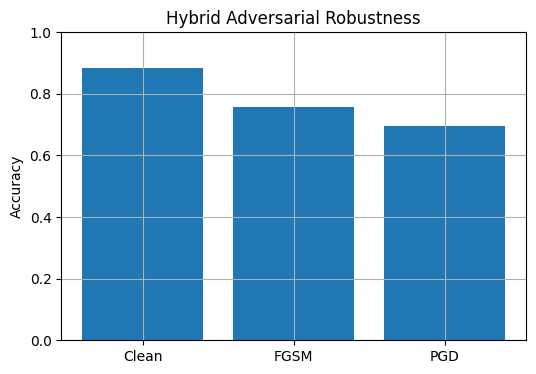

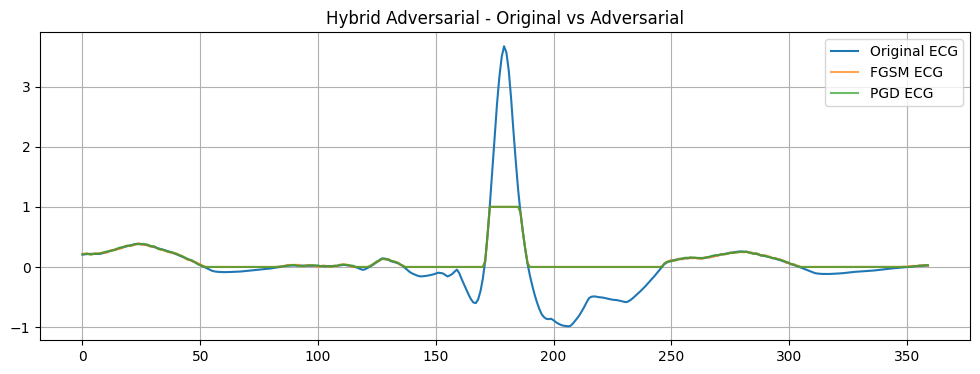

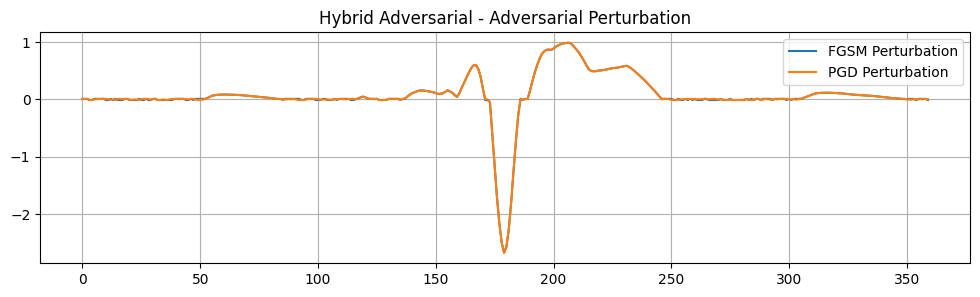

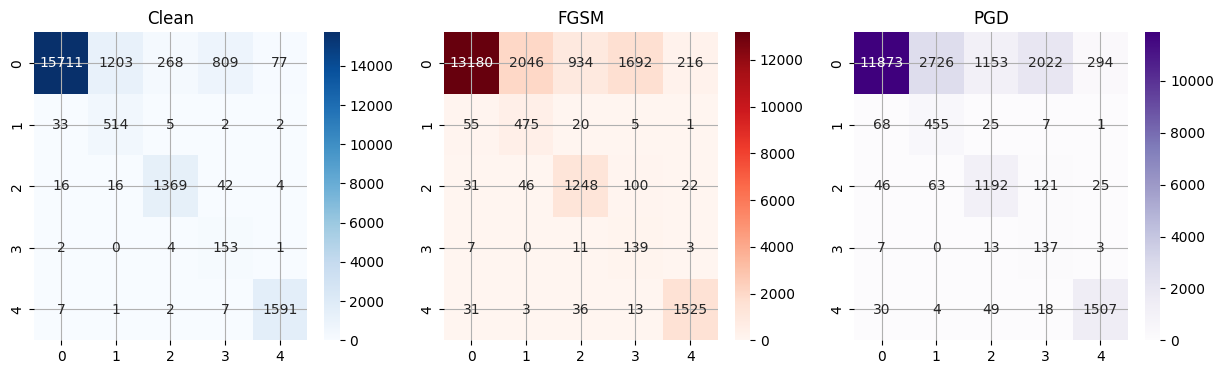

In [ ]:
#### Hybrid Transformer-CNN after adversarial training
hybrid_adv_model = adversarial_training(
    hybrid_model,
    X_train,
    y_train,
    alpha
)

hybrid_adv_test, hybrid_clean_acc, hybrid_fgsm_acc, hybrid_pgd_acc = evaluate_adversarial(
    hybrid_adv_model,
    X_test,
    y_test,
    "Hybrid Adversarial"
)

In [ ]:
def xai_adversarial_analysis(model, X_test, y_test, num_samples=100):

    similarities_fgsm = []
    similarities_pgd = []

    region_shift_fgsm = 0
    region_shift_pgd = 0

    for i in range(num_samples):

        signal = X_test[i]
        label = y_test[i]

        probs = model.predict(signal[np.newaxis], verbose=0)[0]
        pred_class = np.argmax(probs)

        heatmap_clean = make_gradcam_1d(model, signal, pred_class)

        regions_clean, dom_clean = analyze_regions(heatmap_clean)

        #  FGSM
        adv_fgsm = fgsm_attack(
            model,
            signal[np.newaxis],
            label[np.newaxis]
        ).numpy()[0]

        heatmap_fgsm = make_gradcam_1d(model, adv_fgsm, pred_class)

        # Explanation similarity
        sim_fgsm = np.corrcoef(heatmap_clean, heatmap_fgsm)[0,1]
        similarities_fgsm.append(sim_fgsm)

        # Region shift
        regions_fgsm, dom_fgsm = analyze_regions(heatmap_fgsm)

        if dom_clean != dom_fgsm:
            region_shift_fgsm += 1

        #  PGD
        adv_pgd = pgd_attack(
            model,
            signal[np.newaxis],
            label[np.newaxis]
        ).numpy()[0]

        heatmap_pgd = make_gradcam_1d(model, adv_pgd, pred_class)

        sim_pgd = np.corrcoef(heatmap_clean, heatmap_pgd)[0,1]
        similarities_pgd.append(sim_pgd)

        ## Region shift
        regions_pgd, dom_pgd = analyze_regions(heatmap_pgd)

        if dom_clean != dom_pgd:
            region_shift_pgd += 1


    #  Final metrics comparison
    print("\n===== {model_name} XAI + ADVERSARIAL ANALYSIS =====")

    print("FGSM Explanation Similarity:", np.mean(similarities_fgsm))
    print("PGD  Explanation Similarity:", np.mean(similarities_pgd))

    print("FGSM Region Shift Rate:", region_shift_fgsm / num_samples)
    print("PGD  Region Shift Rate:", region_shift_pgd / num_samples)

In [ ]:
xai_adversarial_analysis(cnn_adv_model, X_test, y_test)
xai_adversarial_analysis(resnet_adv_model, X_test, y_test)
xai_adversarial_analysis(hybrid_adv_model, X_test, y_test)

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



===== XAI + ADVERSARIAL ANALYSIS =====
FGSM Explanation Similarity: nan
PGD  Explanation Similarity: nan
FGSM Region Shift Rate: 0.28
PGD  Region Shift Rate: 0.26

===== XAI + ADVERSARIAL ANALYSIS =====
FGSM Explanation Similarity: 0.33503229584033783
PGD  Explanation Similarity: 0.32213947668128
FGSM Region Shift Rate: 0.4
PGD  Region Shift Rate: 0.4

===== XAI + ADVERSARIAL ANALYSIS =====
FGSM Explanation Similarity: nan
PGD  Explanation Similarity: nan
FGSM Region Shift Rate: 0.55
PGD  Region Shift Rate: 0.52


In [ ]:
print("\n===== FINAL COMPARISON =====")

print("Model   | Clean | FGSM | PGD | FGSM Drop | PGD Drop")
print("------------------------------------------------------")

print(f"CNN     | {cnn_clean_acc:.3f} | {cnn_fgsm_acc:.3f} | {cnn_pgd_acc:.3f} | {(cnn_clean_acc-cnn_fgsm_acc):.3f} | {(cnn_clean_acc-cnn_pgd_acc):.3f}")

print(f"ResNet  | {resnet_clean_acc:.3f} | {resnet_fgsm_acc:.3f} | {resnet_pgd_acc:.3f} | {(resnet_clean_acc-resnet_fgsm_acc):.3f} | {(resnet_clean_acc-resnet_pgd_acc):.3f}")

print(f"Hybrid  | {hybrid_clean_acc:.3f} | {hybrid_fgsm_acc:.3f} | {hybrid_pgd_acc:.3f} | {(hybrid_clean_acc-hybrid_fgsm_acc):.3f} | {(hybrid_clean_acc-hybrid_pgd_acc):.3f}")


===== FINAL COMPARISON =====
Model   | Clean | FGSM | PGD | FGSM Drop | PGD Drop
------------------------------------------------------
CNN     | 0.976 | 0.953 | 0.945 | 0.023 | 0.031
ResNet  | 0.960 | 0.881 | 0.856 | 0.079 | 0.105
Hybrid  | 0.885 | 0.759 | 0.694 | 0.127 | 0.191


Dataset-Level Explanation Statistics


In [ ]:
def dataset_explanation_analysis(model, X_data, num_samples=50):

    qrs_focus_count = 0

    for i in range(num_samples):

        signal = X_data[i]

        pred_class = np.argmax(
            model.predict(signal[np.newaxis], verbose=0)
        )

        heatmap = make_gradcam_1d(model, signal, pred_class)

        heatmap_resized = np.interp(
            np.linspace(0, len(heatmap)-1, 360),
            np.arange(len(heatmap)),
            heatmap
        )

        _, dominant = analyze_regions(heatmap_resized)

        if dominant == "QRS":
            qrs_focus_count += 1

    ratio = qrs_focus_count / num_samples

    print(f"QRS Focus Ratio: {ratio:.2f}")

    return ratio


print("\n===== DATASET LEVEL ANALYSIS =====")
print("\nCNN:")
cnn_qrs = dataset_explanation_analysis(cnn_model, X_test)

print("\nResNet:")
resnet_qrs = dataset_explanation_analysis(resnet_model, X_test)

print("\nHybrid:")
hybrid_qrs = dataset_explanation_analysis(hybrid_model, X_test)




print("\n===== FINAL MODEL COMPARISON =====")

header = f"{'Model':<12} | {'Clean':<6} | {'FGSM':<6} | {'PGD':<6} | {'F-Drop':<7} | {'P-Drop':<7} | {'QRS':<5}"
print(header)
print("-" * len(header))

print(f"{'CNN':<12} | {cnn_clean_acc:<6.3f} | {cnn_fgsm_acc:<6.3f} | {cnn_pgd_acc:<6.3f} | {(cnn_clean_acc-cnn_fgsm_acc):<7.3f} | {(cnn_clean_acc-cnn_pgd_acc):<7.3f} | {cnn_qrs:<5.2f}")

print(f"{'ResNet':<12} | {resnet_clean_acc:<6.3f} | {resnet_fgsm_acc:<6.3f} | {resnet_pgd_acc:<6.3f} | {(resnet_clean_acc-resnet_fgsm_acc):<7.3f} | {(resnet_clean_acc-resnet_pgd_acc):<7.3f} | {resnet_qrs:<5.2f}")

print(f"{'Hybrid':<12} | {hybrid_clean_acc:<6.3f} | {hybrid_fgsm_acc:<6.3f} | {hybrid_pgd_acc:<6.3f} | {(hybrid_clean_acc-hybrid_fgsm_acc):<7.3f} | {(hybrid_clean_acc-hybrid_pgd_acc):<7.3f} | {hybrid_qrs:<5.2f}")


===== DATASET LEVEL ANALYSIS =====

CNN:
QRS Focus Ratio: 0.70

ResNet:
QRS Focus Ratio: 0.60

Hybrid:
QRS Focus Ratio: 0.46

===== FINAL MODEL COMPARISON =====
Model        | Clean  | FGSM   | PGD    | F-Drop  | P-Drop  | QRS  
-------------------------------------------------------------------
CNN          | 0.976  | 0.953  | 0.945  | 0.023   | 0.031   | 0.70 
ResNet       | 0.960  | 0.881  | 0.856  | 0.079   | 0.105   | 0.60 
Hybrid       | 0.885  | 0.759  | 0.694  | 0.127   | 0.191   | 0.46 


In [ ]:
correlation_matrix = np.corrcoef(
    [cnn_qrs, resnet_qrs, hybrid_qrs],
    [cnn_pgd_acc, resnet_pgd_acc, hybrid_pgd_acc]
)

correlation_value = correlation_matrix[0,1]

print("Correlation (QRS vs Robustness):", correlation_value)

Correlation (QRS vs Robustness): 0.9975995410172993


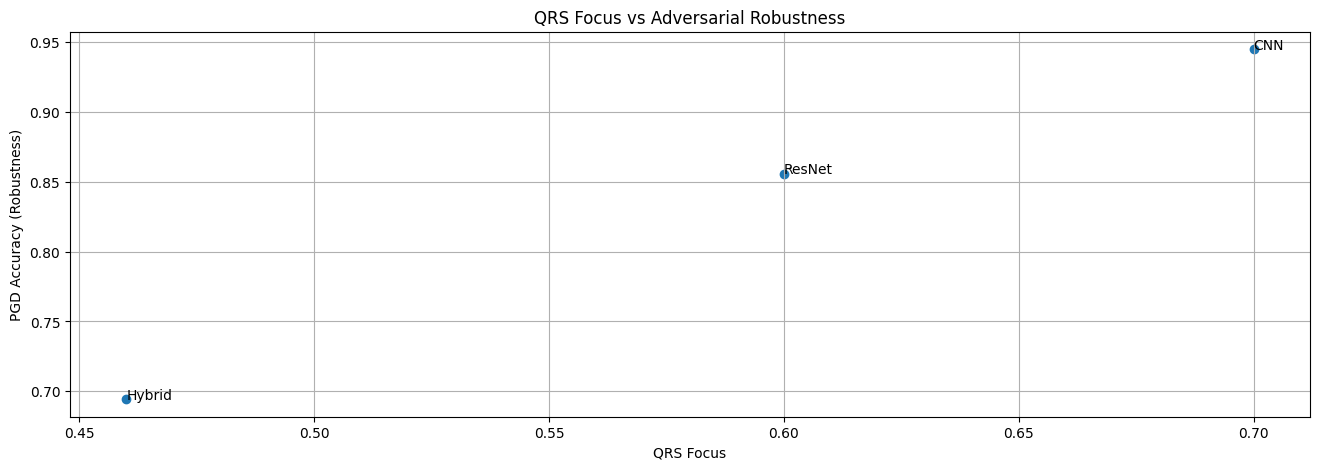

In [ ]:
import matplotlib.pyplot as plt

qrs = [cnn_qrs, resnet_qrs, hybrid_qrs]
pgd = [cnn_pgd_acc, resnet_pgd_acc, hybrid_pgd_acc]

plt.scatter(qrs, pgd)
plt.xlabel("QRS Focus")
plt.ylabel("PGD Accuracy (Robustness)")
plt.title("QRS Focus vs Adversarial Robustness")

for i, label in enumerate(["CNN", "ResNet", "Hybrid"]):
    plt.annotate(label, (qrs[i], pgd[i]))

plt.show()